# EFL League 1 and 2 Player Analysis - Identifying Undervalued Championship-Ready Talent

In [1]:
# Importing some generic libraries that I know will be essential, any specific packages for clustering or visualisation for example will be imported
# in the respective cells they're used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Creating a folder for the figures that I will produce in the final stage and save
import os
os.makedirs("outputs/figures", exist_ok=True)

I have obtained the following data from the Hudl Wyscout platform, all statistics, metrics and player information is derived from this source.

In [3]:
# Reading in the EFL Championship data from 25/26 to provide basline stats to compare to players from League 1 and 2 
champ_def = pd.read_csv('Champ_def_26Baseline.csv')
champ_att = pd.read_csv('Champ_att_26Baseline.csv')

champ_baseline_df = pd.concat([champ_def, champ_att], ignore_index=True)
champ_baseline_df.head()

,Player,Team,Team within selected timeframe,Position,Age,Market value,Contract expires,Matches played,Minutes played,Goals,...,Prevented goals per 90,Back passes received as GK per 90,Exits per 90,Aerial duels per 90.1,Free kicks per 90,Direct free kicks per 90,"Direct free kicks on target, %",Corners per 90,Penalties taken,"Penalty conversion, %"
0,G. Bazunu,Southampton,Stoke City,GK,24.0,15000000,30/06/2027,25,2475,0,...,-0.343,0.00,0.87,0.47,NaN,NaN,NaN,0.00,0,0.0
1,J. Justin,Leeds United,Leicester City,"RB, LB",28.0,15000000,30/06/2029,2,157,0,...,NaN,0.00,NaN,NaN,0.00,0.00,0.00,0.00,0,0.0
2,A. Patterson,Millwall,Millwall,GK,26.0,12000000,30/06/2028,16,1574,0,...,0.134,0.00,0.74,0.11,NaN,NaN,NaN,0.00,0,0.0
3,M. Targett,Middlesbrough,Middlesbrough,"LB, LWB, LCB",30.0,10000000,30/06/2026,45,3967,4,...,NaN,1.00,NaN,NaN,1.25,0.27,41.67,1.50,0,0.0
4,A. Doughty,Millwall,Millwall,"LB, RDMF",26.0,10000000,NaN,27,1580,0,...,NaN,0.68,NaN,NaN,2.22,0.11,0.00,4.44,0,0.0


Constructing dataframes for EFL League 1 and 2 for the 24/25 and 25/26 seasons. When exporting the data from Hudl Wyscout to Excel, only 500 rows could be exported at once, so tables were separated into defensive and attacking players and combined here to make one dataframe per league per season. 

In [4]:
# League 1 25/26
league1_def_26 = pd.read_csv('League1_def_26.csv')
league1_att_26 = pd.read_csv('League1_att_26.csv')

league1_26 = pd.concat([league1_def_26, league1_att_26], ignore_index=True)

# League 1 24/25
league1_def_25 = pd.read_csv('League1_def_25.csv')
league1_att_25 = pd.read_csv('League1_att_25.csv')

league1_25 = pd.concat([league1_def_25, league1_att_25], ignore_index=True)

# League 2 25/26
league2_def_26 = pd.read_csv('League2_def_26.csv')
league2_att_26 = pd.read_csv('League2_att_26.csv')

league2_26 = pd.concat([league2_def_26, league2_att_26], ignore_index=True)

# League 2 24/25
league2_def_25 = pd.read_csv('League2_def_25.csv')
league2_att_25 = pd.read_csv('League2_att_25.csv')

league2_25 = pd.concat([league2_def_25, league2_att_25], ignore_index=True)

Completing some additional checks and finding out some necessary information in preparation for the upcoming analysis.

In [5]:
# Checking number of players in each League to confirm all players are present
for name, df in [("Championship", champ_baseline_df), ("L1 25/26", league1_26), 
                  ("L1 24/25", league1_25), ("L2 25/26", league2_26), 
                  ("L2 24/25", league2_25)]:
    print(f"{name}: {len(df)} players")

Championship: 762 players
L1 25/26: 763 players
L1 24/25: 764 players
L2 25/26: 757 players
L2 24/25: 760 players


In [6]:
# Checking abbreviated names of positions for the upcoming dataframe filtering 
print(league1_26["Position"].value_counts())

Position
CF                 66
GK                 57
CF, AMF            26
RCB                22
LCB                18
                   ..
DMF, RCMF, LCMF     1
AMF, RCMF, RWF      1
LCMF, RCB, RCMF     1
RWF, AMF, RCMF      1
LCMF, RDMF, AMF     1
Name: count, Length: 273, dtype: int64


In [7]:
# Confirming whether all players have a market value entry
print(league1_26["Market value"].notna().mean() * 100)
# However, many are '0' even though the player is not out of contract, so will deal with this problem when completing the market value gap analysis

100.0


In [8]:
# Checking for player duplicates in each dataframe
print(champ_baseline_df.duplicated(subset=["Player", "Team"]).sum())
print(league1_26.duplicated(subset=["Player", "Team"]).sum())
print(league1_25.duplicated(subset=["Player", "Team"]).sum())
print(league2_26.duplicated(subset=["Player", "Team"]).sum())
print(league2_25.duplicated(subset=["Player", "Team"]).sum())

5
9
2
4
8


In [9]:
dupes = league1_26[league1_26.duplicated(subset=["Player", "Team"], keep=False)]
print(dupes[["Player", "Team", "Position", "Minutes played"]].sort_values("Player"))

            Player              Team        Position  Minutes played
670        A. Sasu     AFC Wimbledon         LWB, LW              96
616        A. Sasu     AFC Wimbledon   CF, LWB, RCMF             627
63        B. Hills  Stockport County         CB, RCB            2513
202       B. Hills  Stockport County         RCB, CB             393
571      C. Warren  Bolton Wanderers            LAMF              12
643      C. Warren  Bolton Wanderers            LAMF              12
54     D. Williams           Reading         LCB, CB            2248
203    D. Williams           Reading             LCB             123
73        E. Turns       Exeter City    LCB, RCB, CB            1779
201       E. Turns       Exeter City    RCB, RB, LCB             890
291      J. Koroma     Leyton Orient   RAMF, CF, RWF            1559
664      J. Koroma     Leyton Orient  RAMF, LWF, RWF             290
559     J. Malcolm         Stevenage   RWF, RAMF, CF             221
570     J. Malcolm         Stevena

In [10]:
dupes_player = league1_26[league1_26.duplicated(subset=["Player"], keep=False)]
print(dupes_player[["Player", "Team", "Position", "Minutes played"]].sort_values("Player"))

            Player              Team          Position  Minutes played
616        A. Sasu     AFC Wimbledon     CF, LWB, RCMF             627
670        A. Sasu     AFC Wimbledon           LWB, LW              96
63        B. Hills  Stockport County           CB, RCB            2513
202       B. Hills  Stockport County           RCB, CB             393
663        C. Crew  Doncaster Rovers        LDMF, RDMF             143
577        C. Crew      Leeds United  LDMF, LCMF, RDMF             412
20    C. Humphreys         Port Vale      RCB, CB, LCB            3557
676   C. Humphreys      Ipswich Town   LCMF, RCMF, AMF            1737
571      C. Warren  Bolton Wanderers              LAMF              12
643      C. Warren  Bolton Wanderers              LAMF              12
665       D. Brown               NaN                CF              39
717       D. Brown      Derby County                CF             873
203    D. Williams           Reading               LCB             123
54    

In [11]:
# and creating a function to deal with the few existing duplicates
def resolve_duplicates(df):
    # Sorting so highest minutes row comes first
    df = df.sort_values("Minutes played", ascending=False)
    
    # For true duplicates (same player, team, minutes) simply dropping them
    df = df.drop_duplicates(subset=["Player", "Team", "Minutes played"])
    
    # For remaining duplicates (same player, same team, different minutes)
    # keeping the row with the most minutes - position label will be most representative
    df = df.drop_duplicates(subset=["Player", "Team"], keep="first")
    
    return df.reset_index(drop=True)

league1_26 = resolve_duplicates(league1_26)
league1_25 = resolve_duplicates(league1_25)
league2_26 = resolve_duplicates(league2_26)
league2_25 = resolve_duplicates(league2_25)
champ_baseline_df = resolve_duplicates(champ_baseline_df)

In [12]:
# All duplicates should now have been removed
print(champ_baseline_df.duplicated(subset=["Player", "Team"]).sum())
print(league1_26.duplicated(subset=["Player", "Team"]).sum())
print(league1_25.duplicated(subset=["Player", "Team"]).sum())
print(league2_26.duplicated(subset=["Player", "Team"]).sum())
print(league2_25.duplicated(subset=["Player", "Team"]).sum())

0
0
0
0
0


Now, further cleaning of the dataframes:

In [13]:
# Standardising all column names to remove all possible leading or trailing spaces
league1_26.columns = league1_26.columns.str.strip()
league1_25.columns = league1_25.columns.str.strip()
league2_26.columns = league2_26.columns.str.strip()
league2_25.columns = league2_25.columns.str.strip()
champ_baseline_df.columns = champ_baseline_df.columns.str.strip()

In [14]:
# Establishing a baseline number of minutes played to 900 minutes. Players with less won't have reliable per-90 statistics and so will be dropped
# from the dataframe.
def mins_played_900(df):
    df = df[df["Minutes played"] >= 900]

    return df.reset_index(drop=True)

league1_26 = mins_played_900(league1_26)
league1_25 = mins_played_900(league1_25)
league2_26 = mins_played_900(league2_26)
league2_25 = mins_played_900(league2_25)
champ_baseline_df = mins_played_900(champ_baseline_df)

In [15]:
# Creating a set of reference columns that aren't involved in the statistical analysis but useful for referring to in evaluation
ref_cols = ["Player", "Team", "Age", "Position", "Market value", "Contract expires", "Foot", "Height", 
            "Weight", "Birth country", "Passport country", "On loan", "Team within selected timeframe"]

# Using copies to ensure these are independent dataframes 
league1_26_ref = league1_26[ref_cols].copy()
league1_25_ref = league1_25[ref_cols].copy()
league2_26_ref = league2_26[ref_cols].copy()
league2_25_ref = league2_25[ref_cols].copy()
champ_baseline_ref = champ_baseline_df[ref_cols].copy()

# and dropping some non-analytical columns from the main dataframes
cols_to_drop = ["Birth country", "Passport country", "On loan", "Team"]

league1_26 = league1_26.drop(columns=cols_to_drop)
league1_25 = league1_25.drop(columns=cols_to_drop)
league2_26 = league2_26.drop(columns=cols_to_drop)
league2_25 = league2_25.drop(columns=cols_to_drop)
champ_baseline_df = champ_baseline_df.drop(columns=cols_to_drop)

Now checking for NaN entries. Dealing with them will be specific to each position as each column is only relevant to certain positions on the pitch. For now, I'm getting an idea of which columns have the most NaN entries and if there are any counting stats (eg goals, free kicks, penalties etc) that can immediately be changed to 0. 

In [16]:
#print(league1_26.isnull().mean().sort_values(ascending=False).head(20))
#print(league1_25.isnull().mean().sort_values(ascending=False).head(20))
#print(league2_26.isnull().mean().sort_values(ascending=False).head(20))
#print(league1_25.isnull().mean().sort_values(ascending=False).head(20))
print(champ_baseline_df.isnull().mean().sort_values(ascending=False).head(20))

Conceded goals per 90                0.921225
Shots against per 90                 0.921225
Prevented goals                      0.921225
Aerial duels per 90.1                0.921225
Exits per 90                         0.921225
Prevented goals per 90               0.921225
Contract expires                     0.087527
Direct free kicks on target, %       0.078775
Direct free kicks per 90             0.078775
Free kicks per 90                    0.078775
Foot                                 0.010941
xA per 90                            0.000000
Average long pass length, m          0.000000
Average pass length, m               0.000000
Accurate long passes, %              0.000000
Long passes per 90                   0.000000
Second assists per 90                0.000000
Accurate short / medium passes, %    0.000000
Accurate back passes, %              0.000000
Short / medium passes per 90         0.000000
dtype: float64


Aside from the columns specific to goalkeepers (which will be seperated from the main dataframe in the following steps) and a few bits of missing data from 'Foot' and 'Contract Expires' columns, the only columns with NaNs are with respect to free kick %, which are likely due to the fact that these players haven't taken any free kicks - so I will change just these NaNs to 0 for now.

In [17]:
fk_cols = ["Direct free kicks per 90", "Direct free kicks on target, %", 
           "Free kicks per 90"]
for df in [champ_baseline_df, league1_26, league1_25, league2_26, league2_25]:
    df[fk_cols] = df[fk_cols].fillna(0)

In [18]:
# Printing all possible position abbreviations, so all players can be mapped to a primary role
import re

all_positions = set()
for df in [champ_baseline_df, league1_26, league1_25, league2_26, league2_25]:
    primaries = df["Position"].dropna().apply(lambda x: x.split(",")[0].strip())
    all_positions.update(primaries.unique())

print(sorted(all_positions))

['AMF', 'CB', 'CF', 'DMF', 'GK', 'LAMF', 'LB', 'LCB', 'LCMF', 'LDMF', 'LW', 'LWB', 'LWF', 'RAMF', 'RB', 'RCB', 'RCMF', 'RDMF', 'RW', 'RWB', 'RWF']


In [19]:
# Creating a dictionary to map each player to their primary position (one of 7 categories)
position_mapping = {
    # Goalkeepers
    "GK":   "GoalKeeper",

    # Centre Backs
    "CB":   "Centre Back",
    "RCB":  "Centre Back",
    "LCB":  "Centre Back",

    # Full Backs / Wing Backs
    "RB":   "Full Back",
    "LB":   "Full Back",
    "RWB":  "Full Back",
    "LWB":  "Full Back",

    # Defensive Midfielders — the typical '6'
    "DMF":  "Defensive Midfielder",
    "RDMF": "Defensive Midfielder",
    "LDMF": "Defensive Midfielder",

    # Central / Attacking Midfielders — the typical '8' and '10'
    "LCMF": "Attacking Midfielder",
    "RCMF": "Attacking Midfielder",
    "AMF":  "Attacking Midfielder",
    "RAMF": "Attacking Midfielder",
    "LAMF": "Attacking Midfielder",

    # Wingers
    "RWF":  "Winger",
    "LWF":  "Winger",
    "RW":   "Winger",
    "LW":   "Winger",

    # Centre Forwards / Strikers
    "CF":   "Striker",
}

In [20]:
# Creating a function to apply to the 5 dataframes to map each player according to the above dictionary
def primary_pos_func(df):
    df['Primary Position'] = (df["Position"].str.split(",").str[0].str.strip().map(position_mapping))
    return df

league1_26 = primary_pos_func(league1_26)
league1_25 = primary_pos_func(league1_25)  
league2_26 = primary_pos_func(league2_26)  
league2_25 = primary_pos_func(league2_25)  
champ_baseline_df = primary_pos_func(champ_baseline_df)  

In [21]:
# Checking if all players have been successfully allocated a primary position
for name, df in [("L1 26", league1_26), ("L1 25", league1_25),
                  ("L2 26", league2_26), ("L2 25", league2_25),
                  ("Champ", champ_baseline_df)]:
    nulls = df["Primary Position"].isna().sum()
    print(f"{name}: {nulls} unmapped players")

L1 26: 0 unmapped players
L1 25: 0 unmapped players
L2 26: 0 unmapped players
L2 25: 0 unmapped players
Champ: 0 unmapped players


In [22]:
# and checking the numbers of each
print(league1_26["Primary Position"].value_counts())

Primary Position
Attacking Midfielder    124
Centre Back             101
Full Back                93
Striker                  69
Defensive Midfielder     38
GoalKeeper               33
Winger                   14
Name: count, dtype: int64


Surprisingly, there are only 14 wingers that have played over 900 minutes, which is a very small pool of players. I will need to take this into account when analysing the top candidates and displaying the various graphs and tables.

Now establishing the relevant column statistics for each position, according to the Hudl Wyscout platform.

In [23]:
gk_cols = [
    "Player", "Team within selected timeframe", "Age", "Primary Position", "Minutes played", "Height",
    "Save rate, %", "Prevented goals per 90", "Conceded goals per 90",
    "Shots against per 90", "xG against per 90", "Clean sheets", "Exits per 90",
    "Aerial duels per 90", "Back passes received as GK per 90", 
    "Accurate long passes, %","Passes per 90", "Accurate passes, %"
]

cb_cols = [
    "Player", "Team within selected timeframe", "Age", "Primary Position", "Minutes played", "Height",
    "Defensive duels won, %", "Aerial duels won, %", "Aerial duels per 90",
    "Interceptions per 90", "PAdj Interceptions", "PAdj Sliding tackles", "Shots blocked per 90",
    "Fouls per 90", "Progressive passes per 90", "Accurate progressive passes, %",
    "Accurate long passes, %", "Long passes per 90","Passes per 90", "Accurate passes, %",
    "Successful defensive actions per 90", "Accelerations per 90"
]

fb_cols = [
    "Player", "Team within selected timeframe", "Age", "Primary Position", "Minutes played", "Height",
    "Progressive runs per 90", "Accelerations per 90",
    "Crosses per 90", "Accurate crosses, %",
    "Deep completed crosses per 90", "Assists per 90",
    "Key passes per 90", "Passes to final third per 90",
    "Accurate passes to final third, %",
    "Defensive duels won, %", "PAdj Interceptions",
    "Aerial duels won, %", "Accurate progressive passes, %",
    "Offensive duels won, %", "Touches in box per 90"
]

cdm_cols = [
    "Player", "Team within selected timeframe", "Age", "Primary Position", "Minutes played", "Height",
    "Accurate passes, %", "Progressive passes per 90",
    "Accurate progressive passes, %", "Accelerations per 90",
    "Long passes per 90", "Accurate long passes, %",
    "PAdj Interceptions", "PAdj Sliding tackles",
    "Defensive duels won, %", "Aerial duels won, %",
    "Fouls per 90", "Passes per 90", "Assists per 90",
    "Forward passes per 90", "Accurate forward passes, %"
]

cam_cols = [
    "Player", "Team within selected timeframe", "Age", "Primary Position", "Minutes played", "Height",
    "Key passes per 90", "xA per 90", "Shot assists per 90",
    "Progressive passes per 90", "Accurate progressive passes, %",
    "Passes to final third per 90", "Accurate passes to final third, %",
    "Passes to penalty area per 90", "Accurate passes to penalty area, %",
    "Through passes per 90", "Accurate through passes, %", "Shots per 90",
    "Smart passes per 90", "Accurate smart passes, %", "Fouls suffered per 90",
    "Progressive runs per 90", "Successful dribbles, %",
    "Defensive duels won, %", "Offensive duels won, %", "Accurate passes, %",
    "Deep completions per 90", "Accelerations per 90"
]

wf_cols = [
    "Player", "Team within selected timeframe", "Age", "Primary Position", "Minutes played", "Height",
    "Progressive runs per 90", "Accelerations per 90", "Dribbles per 90",
    "Successful dribbles, %", "Offensive duels won, %",
    "Crosses per 90", "Accurate crosses, %",
    "Deep completed crosses per 90", "Received passes per 90",
    "xA per 90", "Key passes per 90",
    "Passes to final third per 90",
    "Goals per 90", "xG per 90", "Fouls suffered per 90",
    "Shots per 90", "Shots on target, %",
    "Touches in box per 90"
]

cf_cols = [
    "Player", "Team within selected timeframe", "Age", "Primary Position", "Minutes played", "Height",
    "Goals per 90", "xG per 90", "Non-penalty goals per 90",
    "Shots per 90", "Shots on target, %", "Goal conversion, %",
    "xA per 90", "Shot assists per 90", "Accelerations per 90",
    "Touches in box per 90", "Aerial duels won, %",
    "Successful dribbles, %", "Offensive duels won, %",
    "Progressive runs per 90", "Head goals per 90",
    "Deep completions per 90", "Penalty conversion, %"
]

In [24]:
# Dictionary that maps position names to their respective columns
position_cols = {
    "GoalKeeper": gk_cols,
    "Centre Back": cb_cols,
    "Full Back": fb_cols,
    "Defensive Midfielder": cdm_cols,
    "Attacking Midfielder": cam_cols,
    "Winger": wf_cols,
    "Striker": cf_cols
}

# and writing the function that filters by position group and then applies only relevant columns, that will be stored in result
def position_stats(df):
    result = {}
    for position, cols in position_cols.items():
        result[position] = df[df["Primary Position"] == position][cols].reset_index(drop=True)
    return result

league1_26_pos_dfs = position_stats(league1_26)
league1_25_pos_dfs = position_stats(league1_25)
league2_26_pos_dfs = position_stats(league2_26)
league2_25_pos_dfs = position_stats(league2_25)
champ_pos_dfs = position_stats(champ_baseline_df)

Now, briefly verifying the 'per 90' stats are calculated correctly as these metrics are essential to the validity of the model that I will create.

In [25]:
# Some stats where both raw and per 90 are available
verification_pairs = {
    "Goals":        "Goals per 90",
    "Assists":      "Assists per 90",
    "Shots":        "Shots per 90",
    "Yellow cards": "Yellow cards per 90",
    "Red cards":    "Red cards per 90",
}

def verify_per90(df, raw_col, per90_col, tolerance=0.01):
    recalculated = (df[raw_col] / df["Minutes played"]) * 90
    
    diff = (recalculated - df[per90_col]).abs()
    max_diff = diff.max()
    mean_diff = diff.mean()
    mismatches = (diff > tolerance).sum()
    
    print(f"{raw_col} vs {per90_col}:")
    print(f"  Max difference:  {max_diff:.4f}")
    print(f"  Mean difference: {mean_diff:.4f}")
    print(f"  Mismatches (>{tolerance}): {mismatches} players")

cf_df = league1_26[league1_26["Primary Position"] == "Striker"].copy()

for raw_col, per90_col in verification_pairs.items():
    if raw_col in cf_df.columns and per90_col in cf_df.columns:
        verify_per90(cf_df, raw_col, per90_col)

Goals vs Goals per 90:
  Max difference:  0.0050
  Mean difference: 0.0025
  Mismatches (>0.01): 0 players
Assists vs Assists per 90:
  Max difference:  0.0047
  Mean difference: 0.0019
  Mismatches (>0.01): 0 players
Shots vs Shots per 90:
  Max difference:  0.0048
  Mean difference: 0.0024
  Mismatches (>0.01): 0 players
Yellow cards vs Yellow cards per 90:
  Max difference:  0.0048
  Mean difference: 0.0025
  Mismatches (>0.01): 0 players
Red cards vs Red cards per 90:
  Max difference:  0.0044
  Mean difference: 0.0002
  Mismatches (>0.01): 0 players


The above output demonstrates the 'per 90' figures align with the standard formula with any small differences due to rounding (from the categories that I checked). This means these stats can confidently be used in my player analysis and evaluation.

Now focusing on Championship data to establish benchmark profiles to comapre League 1 and 2 players against. Using clustering to visualise the different types of players in each position, each coming with their own statistical profile. 

In [26]:
# Normalising the data first to produce a z-score for all metrics
from sklearn.preprocessing import StandardScaler

def normalise_df(df, exclude_cols=["Player", "Team within selected timeframe", "Age", "Primary Position", "Height"]):
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    
    scaler = StandardScaler()
    normalised = df.copy()
    normalised[feature_cols] = scaler.fit_transform(df[feature_cols])
    
    # Returning normalised dataframe and the fitted scaler which is saved so League 1 and 2 players can be normalised on the same scale later
    return normalised, scaler, feature_cols

In [27]:
# Using the elbow method and matplotlib to visualise the best value of k (number of clusters) from the championship data
from sklearn.cluster import KMeans

def elbow_method(normalised_df, feature_cols, max_k=10, position=""):
    inertias = []
    k_range = range(2, max_k + 1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(normalised_df[feature_cols])
        inertias.append(kmeans.inertia_)

    # Plotting the graphs to display the optimal number of clusters for each position category
    plt.figure(figsize=(8, 4))
    plt.plot(k_range, inertias, marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title(f"Elbow method — {position}")
    plt.xticks(k_range)
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return inertias

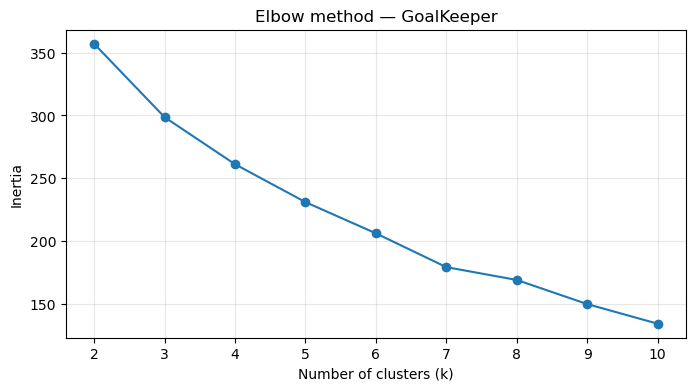

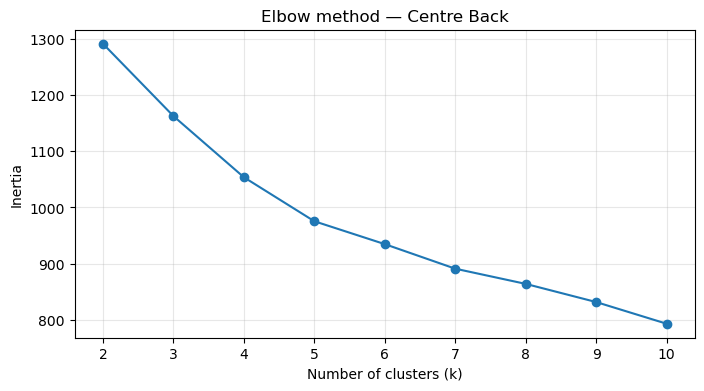

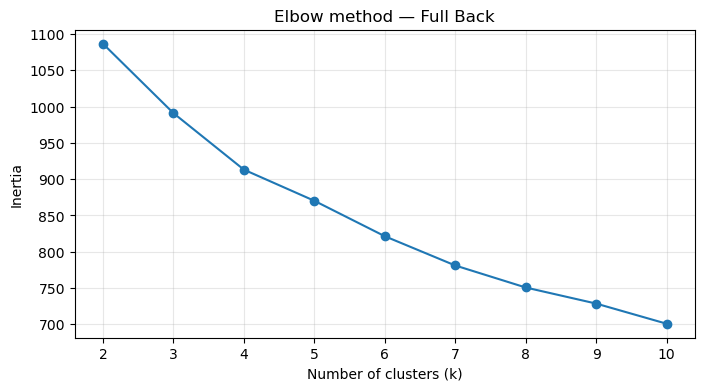

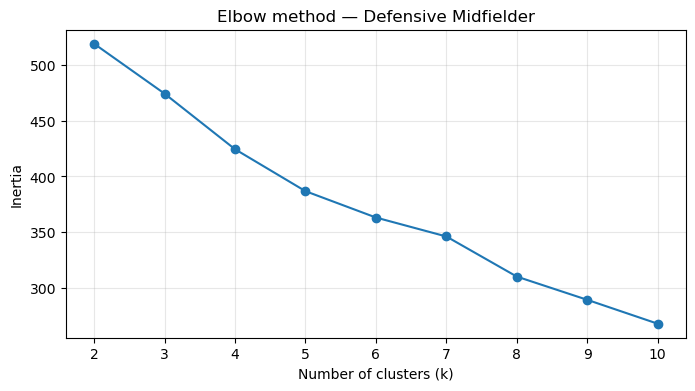

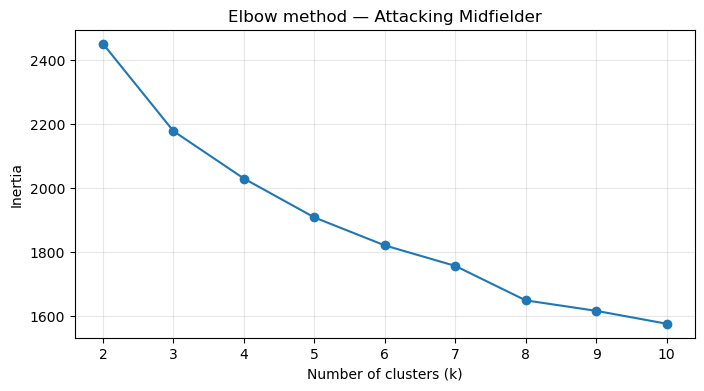

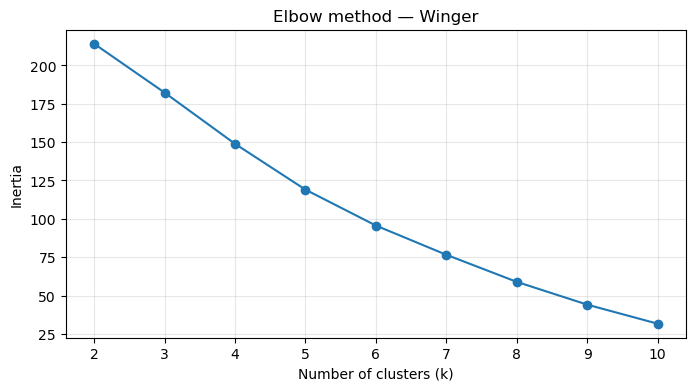

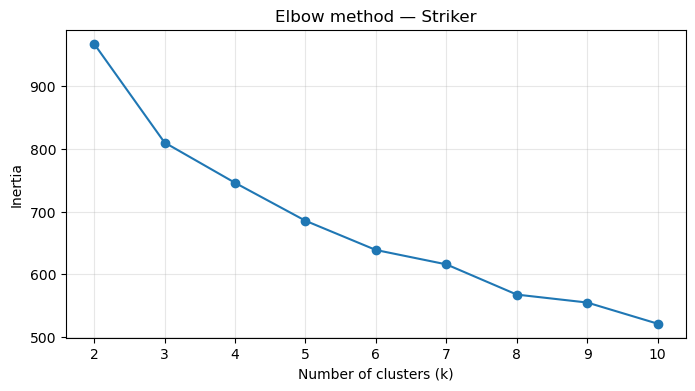

In [28]:
# Looping through all position categories
champ_normalised = {}
champ_scalers = {}
feature_cols_by_pos = {}

for position in champ_pos_dfs.keys():
    original_df = champ_pos_dfs[position]
    normalised_df, scaler, feature_cols = normalise_df(original_df)
    
    champ_normalised[position] = normalised_df
    champ_scalers[position] = scaler
    feature_cols_by_pos[position] = feature_cols

for position in champ_pos_dfs.keys():
    elbow_method(champ_normalised[position], feature_cols_by_pos[position], position=position)

These plots demonstrate rather smooth curves without any particularly sharp elbows, which is unsurprising considering there is significant variation in play style and player-specific attributes. However, based on these graphs and the typical roles of each position, I've chosen the following k-values: GKs: k=3 - slight change in gradient around this point. CBs: k=3 - steepest drop is k=2 to k=3, after which the curve flattens considerably. FBs: k=3 - meaningful drop to k=3, then gradually flattening. DMs: k=3 - clear steeper section up to k=3 then flattening. AMs: k=3 - noticeable change in gradient around k=3. Wingers: k=2. - very smooth curve, but with few wingers over the 900 mins-played mark, it makes more sense to have less clusters. CFs: k=3 - clear elbow at k=3, the steepest drop before the curve noticeably flattens. 

After running the following functions, will be able to classify what each cluster for each position entails (eg ball-playing CB Vs aerial specialist).

In [29]:
# Running the final clustering and saving the label to the championship dataframe
def run_kmeans(normalised_df, feature_cols, k, position=""):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(normalised_df[feature_cols])
    
    result = normalised_df.copy()
    result["cluster"] = labels
    
    print(f"{position}: {k} clusters assigned")
    print(result["cluster"].value_counts().sort_index())
    
    return result, kmeans

In [30]:
# Classifying clusters into certain metrics e.g high xG, low aerial duels won % etc
def profile_clusters(original_df, clustered_normalised_df, feature_cols, position=""):
    original_df = original_df.copy()
    original_df["cluster"] = clustered_normalised_df["cluster"].values
    
    profile = original_df.groupby("cluster")[feature_cols].mean().round(2)
    print(f"\nCluster profiles — {position}")
    print(profile.T)  # transposing the dataframe so metrics are rows, clusters are columns
    
    return original_df, profile

In [31]:
# Creating the dictionary of k-values
k_values = {
    "GoalKeeper": 3,
    "Centre Back": 3,
    "Full Back": 3,
    "Defensive Midfielder": 3,
    "Attacking Midfielder": 3,
    "Winger": 2,
    "Striker": 3
}


# and initialising the empty dictionaries
champ_kmeans   = {}   
champ_clustered = {}  
champ_profiles  = {}  

# looping over all positions with the championship dataframe and storing the results to identify the stats involved in each cluster
for position in k_values:
    result, kmeans = run_kmeans(champ_normalised[position], feature_cols_by_pos[position], k_values[position], position)

    champ_kmeans[position] = kmeans
    champ_clustered[position] = result

    original_with_clusters, profile = profile_clusters(champ_pos_dfs[position], result, feature_cols_by_pos[position], position)
    champ_profiles[position] = profile

GoalKeeper: 3 clusters assigned
cluster
0     5
1    10
2    21
Name: count, dtype: int64

Cluster profiles — GoalKeeper
cluster                                  0        1        2
Minutes played                     1568.80  1809.40  3569.38
Save rate, %                         63.03    63.42    70.89
Prevented goals per 90               -0.21    -0.20     0.01
Conceded goals per 90                 1.72     1.14     1.09
Shots against per 90                  4.73     3.09     3.74
xG against per 90                     1.51     0.93     1.10
Clean sheets                          2.00     4.50     9.57
Exits per 90                          1.42     1.01     1.72
Aerial duels per 90                   0.45     0.31     0.55
Back passes received as GK per 90     0.01     0.00     0.00
Accurate long passes, %              63.05    61.48    61.93
Passes per 90                        24.25    25.74    23.11
Accurate passes, %                   83.15    83.78    83.33
Centre Back: 3 clusters a

Based on the output of the cell above, the seven position categories can be classified into the following clusters:

Goalkeepers - Cluster 0: High shots against, high conceded per 90, low clean sheets, low minutes (hence likely GKs at struggling teams facing lots of shots) - "Busy GK at a weaker team". Cluster 1: Moderate stats across the board, fewer shots faced - "Standard shot-stopper". Cluster 2: Best save rate (70.9%), most clean sheets, most minutes, best prevented goals - "High quality #1"

Centre Backs - Cluster 0: Lower minutes, moderate defensive stats, least progressive passing - "Rotational CB". Cluster 1: High aerial duels, high interceptions, physical and defensive-minded - "Defensive/aerially-dominant CB". Cluster 2:  Highest progressive passes (10.39), most passes per 90, best long pass accuracy - "Ball-playing CB"

Full Backs - Cluster 0:  Fewer crosses, high interceptions, defensive-minded - "Defensive FB". Cluster 1:  Most passes to final third, good progressive passing, but relatively strong defensively - "Balanced FB". Cluster 2: Most crosses (4.06), most progressive runs, most touches in box, most key passes - "Attacking wingback"

Defensive Midfielders - Cluster 0: Fewer passes, more fouls, lower passing accuracy - "Ball-winner DM". Cluster 1: Most progressive passes (9.68), most long passes, most forward passes - "Deep-lying playmaker". Cluster 2: Highest passing accuracy (87.6%), good progressive passing, fewest fouls - "Controlled possession-retaining DM"

Attacking Midfielders - Cluster 0: High passes to final third, good progressive passing, highest pass accuracy - "Progressive passer ('8')". Cluster 1: Most progressive runs, lowest passing stats, most accelerations - "High-pressing ('10')". Cluster 2:  Most key passes, highest xA, most passes to penalty area, most shots - "Creative chance-maker"

Wingers - Cluster 0: More progressive runs, more crosses, higher xA - "Creative/crossing winger". However, this cluster only contains 3 players, which is too small to be a reliable archetype. Hence, when it comes to making comparisons with League 1 and 2 players, will need to be cautious in the evaluations that I make. Cluster 1: More shots, more touches in box, more goals - "Inside forward"

Strikers - Cluster 0: Lowest goals and xG, fewer shots - "Rotational striker". Cluster 1: Highest goals (0.46), best conversion (22%), most aerial duels won - "Clinical & target striker". Cluster 2: Most progressive runs (2.44), most shot assists, most offensive duels - "High-pressing/link-up striker"

In [32]:
# Normalising the League 1 and 2 dataframes with the same scale as the championship (to ensure the comparisons are valid).
# Hence, need to create a function that transforms the League 1 and 2 dataframes using the already-fitted 'champ_scalers[position]'

def normalise_league1and2(df, scaler, feature_cols):  # Using feature_cols as an argument to ensure the exact columns are in the exact order of the 
    normalised = df.copy()                            # original fitting of the scaler on the Championship data
    normalised[feature_cols] = scaler.transform(df[feature_cols])
    return normalised

In [33]:
# Now looping over all position groups of the 4 League 1/2 dataframes 
league1and2_normalised = {
    "league1_26": {},
    "league1_25": {},
    "league2_26": {},
    "league2_25": {}
}

league1and2_pos_dfs = {
    "league1_26": league1_26_pos_dfs,
    "league1_25": league1_25_pos_dfs,
    "league2_26": league2_26_pos_dfs,
    "league2_25": league2_25_pos_dfs
}

for league in league1and2_pos_dfs:
    for position in k_values:
        normalised = normalise_league1and2(league1and2_pos_dfs[league][position], champ_scalers[position], feature_cols_by_pos[position])
        league1and2_normalised[league][position] = normalised

In [34]:
# Defining the cluster labels dictionary for assigning each League 1 and 2 player to their closest Championship cluster
cluster_labels = {
    "GoalKeeper": {0: "Busy GK", 1: "Standard Shot-Stopper", 2: "High Quality #1"},
    "Centre Back": {0: "Rotational CB", 1: "Defensive CB", 2: "Ball-Playing CB"},
    "Full Back": {0: "Defensive FB", 1: "Balanced FB", 2: "Attacking Wingback"},
    "Defensive Midfielder": {0: "Ball-Winner DM", 1: "Deep-Lying Playmaker", 2: "Controlled Possession DM"},
    "Attacking Midfielder": {0: "Progressive Passer", 1: "High-Pressing 10", 2: "Creative Chance-Maker"},
    "Winger": {0: "Creative Winger", 1: "Inside Forward"},
    "Striker": {0: "Rotational Striker", 1: "Clinical & Target Striker", 2: "High-Pressing Link-up Striker"}
}

Having normalised the League 1 and 2 data, and assigned clusters to each position category in the Championship data, I now need to assign each League 1 and 2 player to their nearest Championship cluster to establish how statistically similar they are. Evaluating the overall player quality will be impacted by their cluster label (how desirable their archetype is) and their similarity score (how close they are to that cluster - which I will calculate by computing the Euclidean distance to the centre of each cluster). 

In [35]:
# Writing a function to calculate Euclidean distance to the cenre of each cluster for all players and taking the minimum (ie which they're most
# similar to)
from scipy.spatial.distance import cdist  # I researched this package which computes the pairwise distances between two sets of vectors, which is
                                          # useful for this function for computing Euclidean distance over many rows of a dataframe
def assign_clusters(normalised_df, kmeans, feature_cols, cluster_labels_dict):
    player_features = normalised_df[feature_cols].values
    centroids = kmeans.cluster_centers_  # Obtaining the cluster centroids from fitted kmeans (created during Championship clustering stage)
    
    distances = cdist(player_features, centroids, metric="euclidean") # Computing Euclidean distance from each player to each centroid
    
    nearest_cluster = np.argmin(distances, axis=1)   # Assigning each player to their nearest cluster 
    similarity_score = np.min(distances, axis=1)     # and taking only the minimum similarity score (min. Euclidean distance)
    
    result = normalised_df.copy()
    result["cluster"] = nearest_cluster
    result["cluster_label"] = [cluster_labels_dict[c] for c in nearest_cluster]
    result["similarity_score"] = similarity_score
    
    return result

In [36]:
# Similarly to above, looping over all position groups and dataframes 
league1and2_clustered = {
    "league1_26": {},
    "league1_25": {},
    "league2_26": {},
    "league2_25": {}
}

for league in league1and2_normalised:
    for position in k_values:
        result = assign_clusters(
            league1and2_normalised[league][position], 
            champ_kmeans[position],                    
            feature_cols_by_pos[position],
            cluster_labels[position]
        )
        league1and2_clustered[league][position] = result  # Writing into the empty dictionaries of clustered data

In [37]:
# Displaying some players to get an idea of label variation and range of similarity scores
print(league1and2_clustered["league1_26"]["Striker"][["Player", "Team within selected timeframe", "cluster_label", "similarity_score"]].head(10))

        Player Team within selected timeframe              cluster_label  \
0   K. Wootton               Stockport County         Rotational Striker   
1   J. Beesley                  Burton Albion         Rotational Striker   
2      J. Reid                      Stevenage         Rotational Striker   
3   J. Wareham                    Exeter City  Clinical & Target Striker   
4   D. Ballard                  Leyton Orient  Clinical & Target Striker   
5     W. Evans                 Mansfield Town         Rotational Striker   
6  A. Fletcher                      Blackpool         Rotational Striker   
7    R. Street                   Lincoln City         Rotational Striker   
8   H. Leonard            Peterborough United  Clinical & Target Striker   
9     L. Tolaj                Plymouth Argyle  Clinical & Target Striker   

   similarity_score  
0          5.810005  
1          4.605542  
2          3.652820  
3          3.942406  
4          3.694799  
5          2.660510  
6        

Within just these 10 League 1 Strikers, there's an extensive range of similarity scores. This is to be expected considering many League 1 and 2 players won't share a similar profile to players in the Championship as the typical style of play for teams as you descend down the leagues alters in many ways. Hence, I need to establish a threshold score for what makes a credible candidate. 

In [38]:
# Checking the distribution of scores of all positions to find a 'natural' cutoff
for position in k_values:
    scores = league1and2_clustered["league1_26"][position]["similarity_score"]
    print(f"\n{position}")
    print(f"  Mean: {scores.mean():.2f}  Min: {scores.min():.2f}  Max: {scores.max():.2f}  25th %ile: {scores.quantile(0.25):.2f}")


GoalKeeper
  Mean: 3.40  Min: 1.87  Max: 6.26  25th %ile: 2.79

Centre Back
  Mean: 3.99  Min: 2.59  Max: 6.81  25th %ile: 3.26

Full Back
  Mean: 3.77  Min: 2.04  Max: 7.12  25th %ile: 2.94

Defensive Midfielder
  Mean: 3.90  Min: 2.22  Max: 6.66  25th %ile: 3.33

Attacking Midfielder
  Mean: 4.17  Min: 2.31  Max: 6.94  25th %ile: 3.58

Winger
  Mean: 4.67  Min: 1.89  Max: 6.23  25th %ile: 4.02

Striker
  Mean: 3.77  Min: 2.09  Max: 6.34  25th %ile: 3.25


Based on the above output, I'm going to choose the 25th Percentile as the threshold. This will be implemented in the following stage of market value gap analysis - where I aim to identify the players who are statistically similar to Championship players but whose market value hasn't caught up with their performance level.

In [39]:
# Need to first establish what Championship players in each cluster are usually worth, so obtaining median market value per cluster for Championship
# players  in each position group.
def get_champ_cluster_values(position):
    champ_df = champ_clustered[position].copy()

    # Joining market values from reference dataframe created earlier on
    champ_df = champ_df.merge(champ_baseline_ref[["Player", "Market value"]], on="Player", how="left")
    
    champ_df["cluster_label"] = champ_df["cluster"].map(cluster_labels[position])   # Adding cluster label
    cluster_medians = champ_df.groupby("cluster_label")["Market value"].median()    # and obtaining median
    
    return cluster_medians

In [40]:
# Writing a function to establish the market value gap of each League 1 and 2 player who lies within the top 25 percent of similarity scores 
# (market value gap calculated by: Championship cluster median - player market value)
def calculate_value_gap(clustered_df, ref_df, champ_cluster_medians, position, league, season):
    
    threshold = clustered_df["similarity_score"].quantile(0.25)  # Applying 25th percentile similarity threshold
    candidates = clustered_df[clustered_df["similarity_score"] <= threshold].copy()
    
    # Same as above, joining market value from reference dataframe
    candidates = candidates.merge(ref_df[["Player", "Market value", "Contract expires"]], on="Player", how="left")
    
    candidates["champ_cluster_median_value"] = candidates["cluster_label"].map(champ_cluster_medians)
    
    candidates["value_gap"] = candidates["champ_cluster_median_value"] - candidates["Market value"]   # Calculating the market value gap

    candidates["value_gap_pct"] = (     # Also calculating percentage value gap, which is a fairer metric than gross difference in value
    (candidates["champ_cluster_median_value"] - candidates["Market value"]) 
    / candidates["champ_cluster_median_value"] * 100
    ).round(1)
    
    candidates["league"] = league      # and adding useful metadata
    candidates["season"] = season
    candidates["position"] = position
    
    candidates = candidates.sort_values("value_gap", ascending=False)
    
    return candidates

In [41]:
# Looping over all League 1 and 2 dataframes but this time storing in a combined dataframe 'all_candidates_df'
all_candidates = []

league_seasons = {
    "league1_26": "25/26",
    "league1_25": "24/25",
    "league2_26": "25/26",
    "league2_25": "24/25"
}

league1and2_ref_dfs = {              # Mapping each league key string to its reference df
    "league1_26": league1_26_ref,    
    "league1_25": league1_25_ref,
    "league2_26": league2_26_ref,
    "league2_25": league2_25_ref
}

for league in league1and2_clustered:
    for position in k_values:
        champ_medians = get_champ_cluster_values(position)
        
        ref_df = league1and2_ref_dfs[league]
        
        candidates = calculate_value_gap(league1and2_clustered[league][position], ref_df, champ_medians, position, league, league_seasons[league])
        all_candidates.append(candidates)

all_candidates_df = pd.concat(all_candidates, ignore_index=True)  # and combining into the singular dataframe

all_candidates_df = all_candidates_df.rename(columns={"Age_x": "Age"})
all_candidates_df = all_candidates_df.drop(columns=["Age_y"], errors="ignore")

I encountered repeated errors with respect to the 'Age' column in the all_candidates_df so I removed the 'Age' column from the 'candidates.merge()' line within the calculate_value_gap function above and added the 'Age' column here - to the already created all_candidates_df.

Now going through some checks for this newly created all_candidates_df:

In [42]:
all_candidates_df.shape

(495, 74)

In [43]:
print(all_candidates_df.groupby(["league", "position"]).size().reset_index(name="count"))

        league              position  count
0   league1_25  Attacking Midfielder     30
1   league1_25           Centre Back     28
2   league1_25  Defensive Midfielder     13
3   league1_25             Full Back     23
4   league1_25            GoalKeeper     10
5   league1_25               Striker     20
6   league1_25                Winger      3
7   league1_26  Attacking Midfielder     31
8   league1_26           Centre Back     27
9   league1_26  Defensive Midfielder     10
10  league1_26             Full Back     24
11  league1_26            GoalKeeper      9
12  league1_26               Striker     18
13  league1_26                Winger      4
14  league2_25  Attacking Midfielder     31
15  league2_25           Centre Back     26
16  league2_25  Defensive Midfielder      8
17  league2_25             Full Back     26
18  league2_25            GoalKeeper      9
19  league2_25               Striker     21
20  league2_25                Winger      2
21  league2_26  Attacking Midfie

In [44]:
print(all_candidates_df[["Player", "Team within selected timeframe", "position", 
                           "league", "season", "cluster_label", 
                           "similarity_score", "Market value", 
                           "champ_cluster_median_value", 
                           "value_gap"]].head(20))

           Player Team within selected timeframe     position      league  \
0       K. Cahill                  Leyton Orient   GoalKeeper  league1_26   
1   B. Hinchliffe               Stockport County   GoalKeeper  league1_26   
2       J. Bonham               Bolton Wanderers   GoalKeeper  league1_26   
3       J. Keeley                     Luton Town   GoalKeeper  league1_26   
4    Joel Pereira                        Reading   GoalKeeper  league1_26   
5       N. Bishop                  AFC Wimbledon   GoalKeeper  league1_26   
6       T. Simkin                  Leyton Orient   GoalKeeper  league1_26   
7     L. Nicholls              Huddersfield Town   GoalKeeper  league1_26   
8        J. Gauci                      Port Vale   GoalKeeper  league1_26   
9         J. Kerr                 Wigan Athletic  Centre Back  league1_26   
10       T. Allen              Wycombe Wanderers  Centre Back  league1_26   
11    J. Shepherd                       Barnsley  Centre Back  league1_26   

The above output shows the model is working effectively - identifying the realistic value gaps and also presence of negative value gaps (ie already valued at Championship level despite playing and likely underperforming in League 1/2). However, there are some players above with a 0 market value, so will need to investigate this further.

In [45]:
zero_count = (all_candidates_df["Market value"] == 0).sum()
total = len(all_candidates_df)
print(f"Zero market value: {zero_count} ({zero_count/total*100:.1f}%)")

Zero market value: 118 (23.8%)


In [46]:
zero_mv = all_candidates_df[all_candidates_df["Market value"] == 0]
print(zero_mv["Age"].describe())
print(zero_mv["league"].value_counts())
print(zero_mv["position"].value_counts())

count    118.000000
mean      23.923729
std        3.850090
min       18.000000
25%       21.000000
50%       23.000000
75%       25.000000
max       35.000000
Name: Age, dtype: float64
league
league2_26    46
league2_25    30
league1_25    21
league1_26    21
Name: count, dtype: int64
position
Attacking Midfielder    37
Full Back               25
Striker                 24
Centre Back             17
GoalKeeper               6
Winger                   5
Defensive Midfielder     4
Name: count, dtype: int64


Since 118 of the 495 players in the candidate dataframe have no identified market value from the Wysout platform, and the mean age of these players is ~ 24 years old (prime development and high market value age) it would significantly impact my evaluation if I were to remove these players from the candidate dataframe. I considered implementing Transfermarkt data but after looking into it, this option seems overly complex and messy for the relatively small gain, so doesn't seem to be the best alternative. Hence, I'm going to create a 'watchlist' that contains the players in this candidate dataframe who have an assigned market value of 0, and so they will appear in the output and final evaluation but separately from those with an established market value gap.

In [47]:
# Separating the all_candidates_df into 'valued_candidates' and the 'watchlist_candidates'
valued_candidates_df = all_candidates_df[all_candidates_df["Market value"] > 0].copy()
watchlist_candidates_df = all_candidates_df[all_candidates_df["Market value"] == 0].copy()

print(f"Valued candidates: {len(valued_candidates_df)}")
print(f"Watchlist candidates: {len(watchlist_candidates_df)}")

Valued candidates: 377
Watchlist candidates: 118


In [48]:
# Now seaparating the two dataframes into age bands
def assign_age_band(age):
    if age <= 20:
        return "Young talent - U21"
    elif age <= 24:
        return "Prime developing"
    elif age <= 29:
        return "Peak years"
    else:
        return "Experienced"

# and applying to both dataframes
valued_candidates_df["Age band"] = valued_candidates_df["Age"].apply(assign_age_band)
watchlist_candidates_df["Age band"] = watchlist_candidates_df["Age"].apply(assign_age_band)

In [49]:
# Checking the value counts
print(valued_candidates_df["Age band"].value_counts())
print(watchlist_candidates_df["Age band"].value_counts())

Age band
Peak years            166
Experienced           127
Prime developing       83
Young talent - U21      1
Name: count, dtype: int64
Age band
Prime developing      63
Peak years            29
Young talent - U21    14
Experienced           12
Name: count, dtype: int64


The fact that there's only 1 U21 in the 'valued_candidates_df' and 14 in the 'watchlist_candidates_df' suggests many of the young talents that formed the original 'all_candidates_df' were too young to have an established market value on the Wyscout platform. This is why it's important that the players with no market value weren't dropped from the evaluation. This potentially suggests that some of the most undervalued players by age are almost invisible to some market evaluation systems. 

Also, the fact that the 'Peak years' and 'Experienced' bands are dominant - particularly within the valued candidates - further suggests that young players in League 1 and 2 tend to not have an established market value yet or alternatively, more experienced players are a closer statistical fit to Championship archetypes, with several having played at that level earlier in their career.

In [50]:
# Now carrying out a consistency check, identifying which players appears in the valued and watchlist dataframes from both the 25/26 and 24/25 
# campaigns to further group the candidates into those that have performed to a high level in both seasons and those that haven't
primary_season = valued_candidates_df[valued_candidates_df["season"] == "25/26"][["Player", "league"]]
prior_season = valued_candidates_df[valued_candidates_df["season"] == "24/25"][["Player", "league"]]

valued_candidates_merge = primary_season.merge(prior_season, on='Player', how='left')

conditions = [
    valued_candidates_merge["league_x"] == valued_candidates_merge["league_y"],           # These are the one-league consistent and cross-league
    (valued_candidates_merge["league_x"] != valued_candidates_merge["league_y"]) &        # consistent conditions
    (valued_candidates_merge["league_y"].notna()),
]

choices = [
    "Same-league consistent",
    "Cross-league consistent"
]

valued_candidates_merge["consistency"] = np.select(conditions, choices, default="One season - less consistent")

In [51]:
# Joining the consistency check back onto primary season candidates (only)
valued_candidates_df = valued_candidates_df.drop(columns=["consistency"], errors="ignore")  # This cell was returning error so added this line to 
                                                                                            # prevent problems with merging errors when re-running
consistency_map = valued_candidates_merge[["Player", "consistency"]].drop_duplicates()

valued_candidates_df = valued_candidates_df.merge(
    consistency_map,
    on="Player",
    how="left"
)

# Rows with players in 24/25 don't need a consistency flag so filling with the following label
valued_candidates_df["consistency"] = valued_candidates_df["consistency"].fillna("24/25 reference only")

print(valued_candidates_df["consistency"].value_counts())

consistency
24/25 reference only            154
One season - less consistent    133
Cross-league consistent          90
Name: count, dtype: int64


I want to also consider the young players whose first proper campaign was the 25/26 season. I don't want to exclude these players who would otherwise be flagged as less consistent, so for any player who is 21 or under and has only played one season, will classify into their own catgeory.

In [52]:
valued_candidates_df.loc[
    (valued_candidates_df["consistency"] == "One season - less consistent") & 
    (valued_candidates_df["Age"] <= 21),
    "consistency"
] = "Early career - insufficient data"

print(valued_candidates_df["consistency"].value_counts())

consistency
24/25 reference only                154
One season - less consistent        129
Cross-league consistent              90
Early career - insufficient data      4
Name: count, dtype: int64


In [53]:
# Now carrying out the same consistency check on the watchlist_candidates_df
primary_season = watchlist_candidates_df[watchlist_candidates_df["season"] == "25/26"][["Player", "league"]]
prior_season = watchlist_candidates_df[watchlist_candidates_df["season"] == "24/25"][["Player", "league"]]

watchlist_candidates_merge = primary_season.merge(prior_season, on='Player', how='left')

conditions = [
    watchlist_candidates_merge["league_x"] == watchlist_candidates_merge["league_y"],
    (watchlist_candidates_merge["league_x"] != watchlist_candidates_merge["league_y"]) & 
    (watchlist_candidates_merge["league_y"].notna()),
]

choices = [
    "Same-league consistent",
    "Cross-league consistent"
]

watchlist_candidates_merge["consistency"] = np.select(conditions, choices, default="One season - less consistent")

# Joining back onto watchlist_candidates_df
watchlist_candidates_df = watchlist_candidates_df.drop(columns=["consistency"], errors="ignore")  
                                                                                            
consistency_map = watchlist_candidates_merge[["Player", "consistency"]].drop_duplicates()

watchlist_candidates_df = watchlist_candidates_df.merge(
    consistency_map,
    on="Player",
    how="left"
)

watchlist_candidates_df["consistency"] = watchlist_candidates_df["consistency"].fillna("24/25 reference only")

# and adding the U21 category
watchlist_candidates_df.loc[
    (watchlist_candidates_df["consistency"] == "One season - less consistent") & 
    (watchlist_candidates_df["Age"] <= 21),
    "consistency"
] = "Early career - insufficient data"

print(watchlist_candidates_df["consistency"].value_counts())

consistency
24/25 reference only                44
One season - less consistent        38
Early career - insufficient data    22
Cross-league consistent             14
Name: count, dtype: int64


In [54]:
# Filtering out the 24/25 reference players and checking how many candidates there are
valued_candidates_df = valued_candidates_df[valued_candidates_df["consistency"] != "24/25 reference only"]
watchlist_candidates_df = watchlist_candidates_df[watchlist_candidates_df["consistency"] != "24/25 reference only"]

print(f"Number of valued candidates: {len(valued_candidates_df)}")
print(f"Number of watchlist candidates: {len(watchlist_candidates_df)}")

Number of valued candidates: 223
Number of watchlist candidates: 74


In [55]:
# Removing any existing duplicates in these final dataframes and displaying final counts
valued_candidates_df = valued_candidates_df.sort_values("similarity_score", ascending=True)
valued_candidates_df = valued_candidates_df.drop_duplicates(subset=["Player", "position"], keep="first")

watchlist_candidates_df = watchlist_candidates_df.sort_values("similarity_score", ascending=True)
watchlist_candidates_df = watchlist_candidates_df.drop_duplicates(subset=["Player", "position"], keep="first")

print(f"Final valued candidates: {len(valued_candidates_df)}")
print(f"Final watchlist candidates: {len(watchlist_candidates_df)}")

Final valued candidates: 180
Final watchlist candidates: 67


The analysis stage is now complete. All League 1 and 2 players from the last two seasons have been narrowed down into suitable candidates, based on my statistical model, into 'valued candidates' - those who are performing above their market value and fit a Championship player profile and 'watchlist candidates' - those who have no recognised market value according to the Wyscout data platform but also fit a Championship player profile, many of whom are young, developing players. 

The final stage of this project is the data visualisation, so that I can evaluate from the select group of candidates who should be key target signings for clubs in the EFL Championship. 

In [56]:
# First, checking I can use mplsoccer - for football-specific plots and charts
!pip install mplsoccer

  Using cached mplsoccer-1.6.1-py3-none-any.whl.metadata (4.8 kB)
Using cached mplsoccer-1.6.1-py3-none-any.whl (88 kB)


In [57]:
# Creating shortlist tables to display some of the top candidates per position group for the valued candidates
def shortlist_groups(valued_candidates_df, position, n=10):
    df = valued_candidates_df[valued_candidates_df['position'] == position].copy()

    cols_to_display = [
        "Player", "Team within selected timeframe", "Age", 
        "Age band", "cluster_label", "similarity_score",
        "Market value", "champ_cluster_median_value", 
        "value_gap", "value_gap_pct", "consistency", "Contract expires"
    ]

    df = df.sort_values(["value_gap_pct", "similarity_score"], ascending=[False, True])  # Want the table to be ranked with value gap in descending
                                                                                         # order but similarity score ascending (smaller the value 
    print(f"\nTop {n} {position} candidates:")                                           # the better)
    print(df[cols_to_display].head(n).to_string(index=False))
    
    return df[cols_to_display].head(n)

# looping over position groups to obtain position-specific shortlist tables
shortlists = {}
for position in k_values:
    shortlists[position] = shortlist_groups(valued_candidates_df, position)


Top 10 GoalKeeper candidates:
       Player Team within selected timeframe  Age         Age band         cluster_label  similarity_score  Market value  champ_cluster_median_value  value_gap  value_gap_pct                  consistency Contract expires
B. Hinchliffe               Stockport County 37.0      Experienced Standard Shot-Stopper          1.870997        100000                   1200000.0  1100000.0           91.7 One season - less consistent              NaN
    J. Murphy                Tranmere Rovers 44.0      Experienced               Busy GK          2.541809         25000                    300000.0   275000.0           91.7 One season - less consistent       30/06/2026
    I. Lawlor                Crewe Alexandra 31.0      Experienced       High Quality #1          2.354094         75000                    700000.0   625000.0           89.3 One season - less consistent       30/06/2027
   J. Belshaw                   Notts County 35.0      Experienced       High Quality

The shortlist tables above ranked by value gap and similarity score show many position groups being dominated by a single archetype - likely the one with the lowest median Championship market value. Hence, to best identify top candidates across different playing styles, I'm going to use a cluster-balanced shortlist function, which will return the top players from each cluster separately - to hopefully provide a more representative output.

In [58]:
# With this function, only the top 3 candidates per cluster (archetype) will be displayed
def shortlist_by_cluster(valued_candidates_df, position, n_per_cluster=3, max_age=36):  
    df = valued_candidates_df[valued_candidates_df["position"] == position].copy()
    df = df[df["Age"] <= max_age]    # filtering out those older than 36, as these are more unrealistic signings
    
    result = []
    for cluster in df["cluster_label"].unique():
        cluster_df = df[df["cluster_label"] == cluster]
        cluster_df = cluster_df.sort_values(
            ["value_gap_pct", "similarity_score"],
            ascending=[False, True]
        )
        result.append(cluster_df.head(n_per_cluster))
    
    return pd.concat(result).reset_index(drop=True)

shortlists_by_cluster = {}
for position in k_values:
    shortlists_by_cluster[position] = shortlist_by_cluster(valued_candidates_df, position)


cols_to_display = [
    "Player", "Team within selected timeframe", "Age",
    "Age band", "cluster_label", "similarity_score",
    "Market value", "champ_cluster_median_value",
    "value_gap", "value_gap_pct", "consistency", "Contract expires"
]

for position, df in shortlists_by_cluster.items():
    print(f"\n{'='*60}")
    print(f"Top candidates by cluster — {position}")
    print(f"{'='*60}")
    print(df[cols_to_display].to_string(index=False))


Top candidates by cluster — GoalKeeper
      Player Team within selected timeframe  Age         Age band         cluster_label  similarity_score  Market value  champ_cluster_median_value  value_gap  value_gap_pct                  consistency Contract expires
L. Southwood               Bolton Wanderers 28.0       Peak years Standard Shot-Stopper          1.599992        500000                   1200000.0   700000.0           58.3      Cross-league consistent       30/06/2027
   J. Bonham               Bolton Wanderers 32.0      Experienced Standard Shot-Stopper          2.503673        500000                   1200000.0   700000.0           58.3 One season - less consistent       30/06/2027
 L. Nicholls              Huddersfield Town 33.0      Experienced Standard Shot-Stopper          1.188656        900000                   1200000.0   300000.0           25.0      Cross-league consistent       30/06/2028
   I. Lawlor                Crewe Alexandra 31.0      Experienced       High Qua

The Winger position is an issue, noted earlier on caused by the lack of wingers that have played over 900 minutes across the season. This made this position category very narrow when filtering into the top candidates and means the evaluation and graphs displayed for this position won't be as effective as the other categories with a more extensive pool of players.

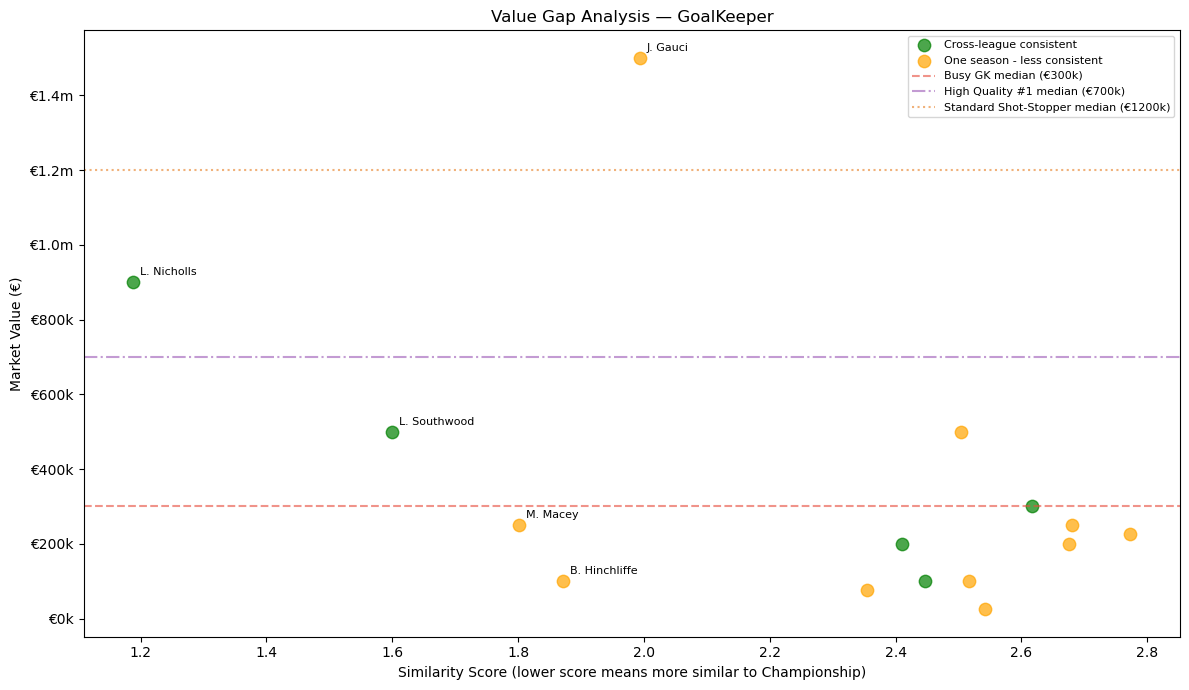

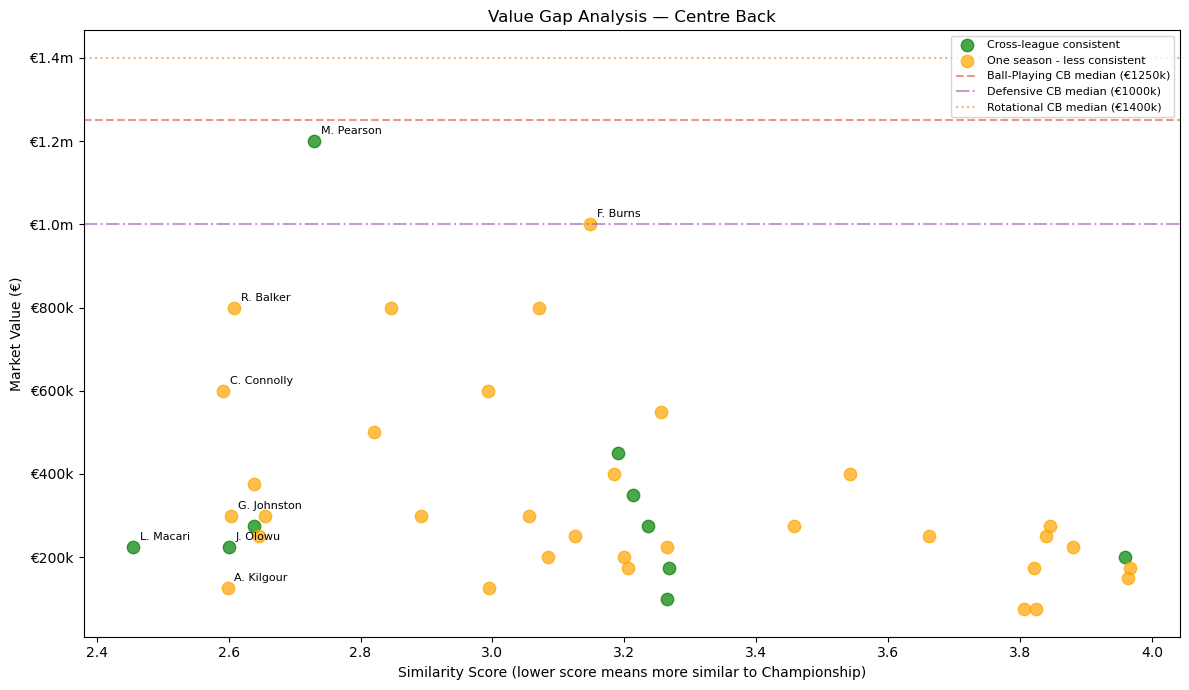

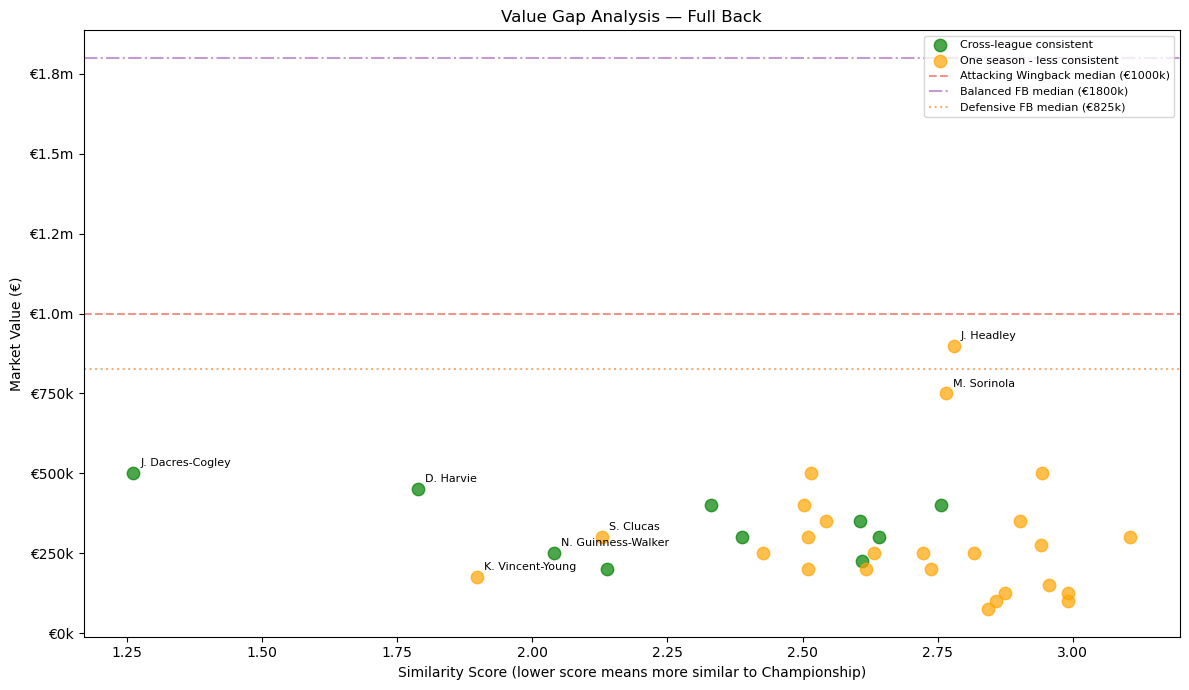

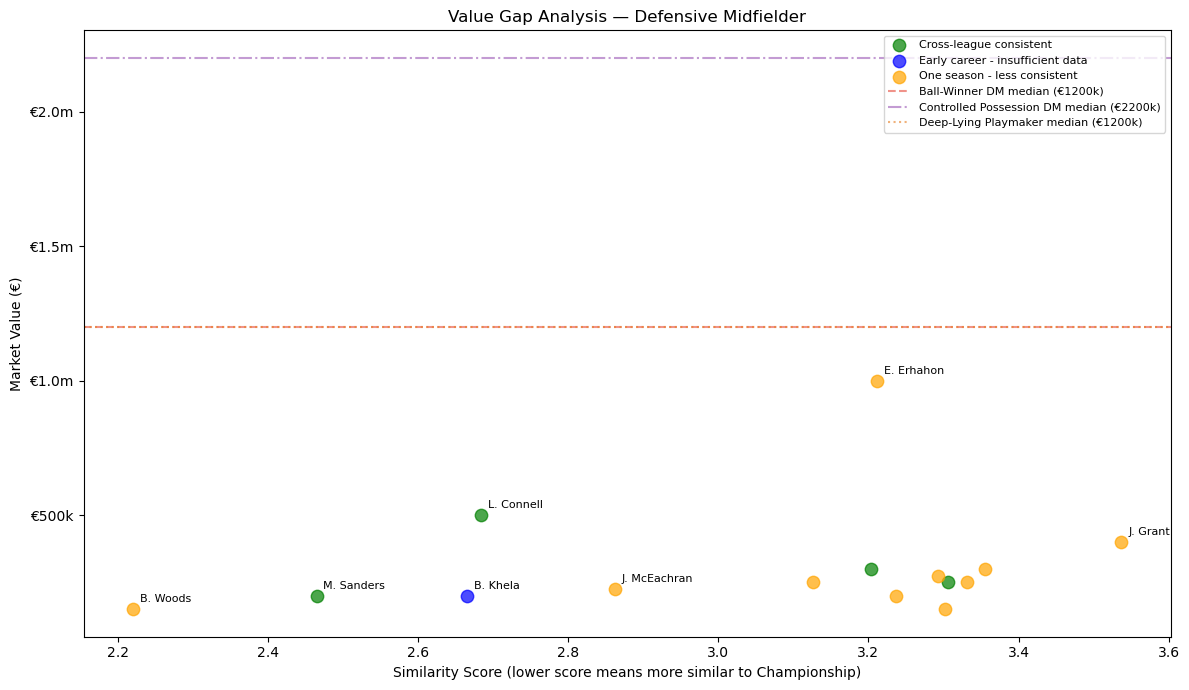

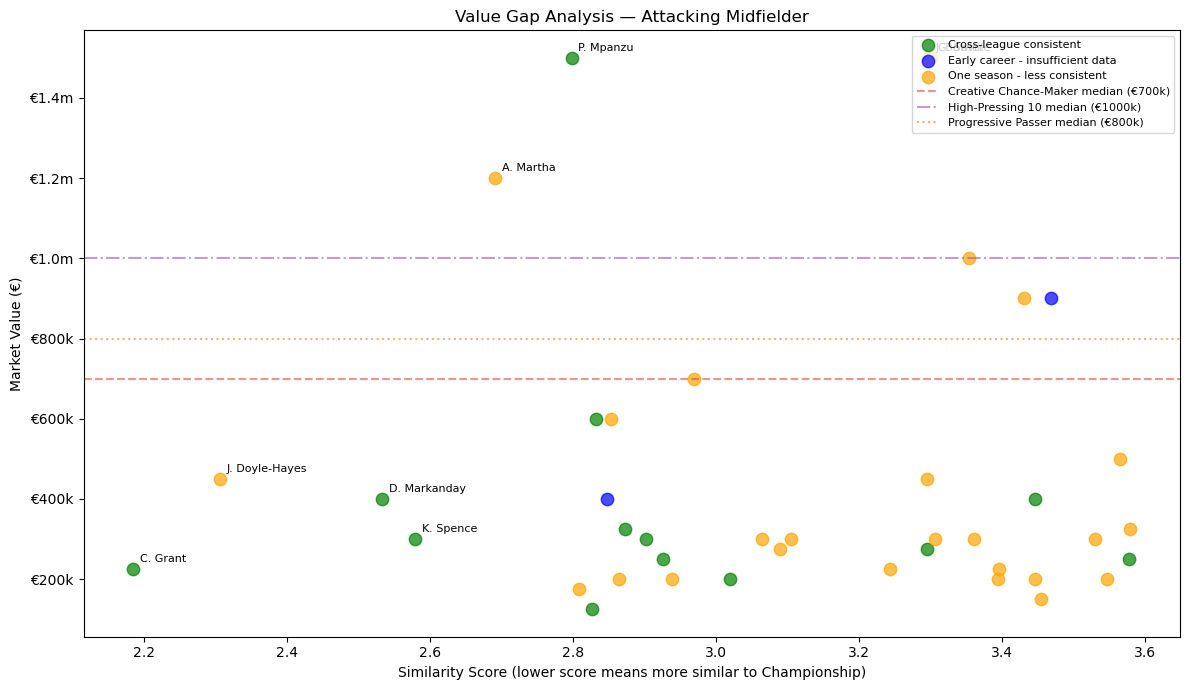

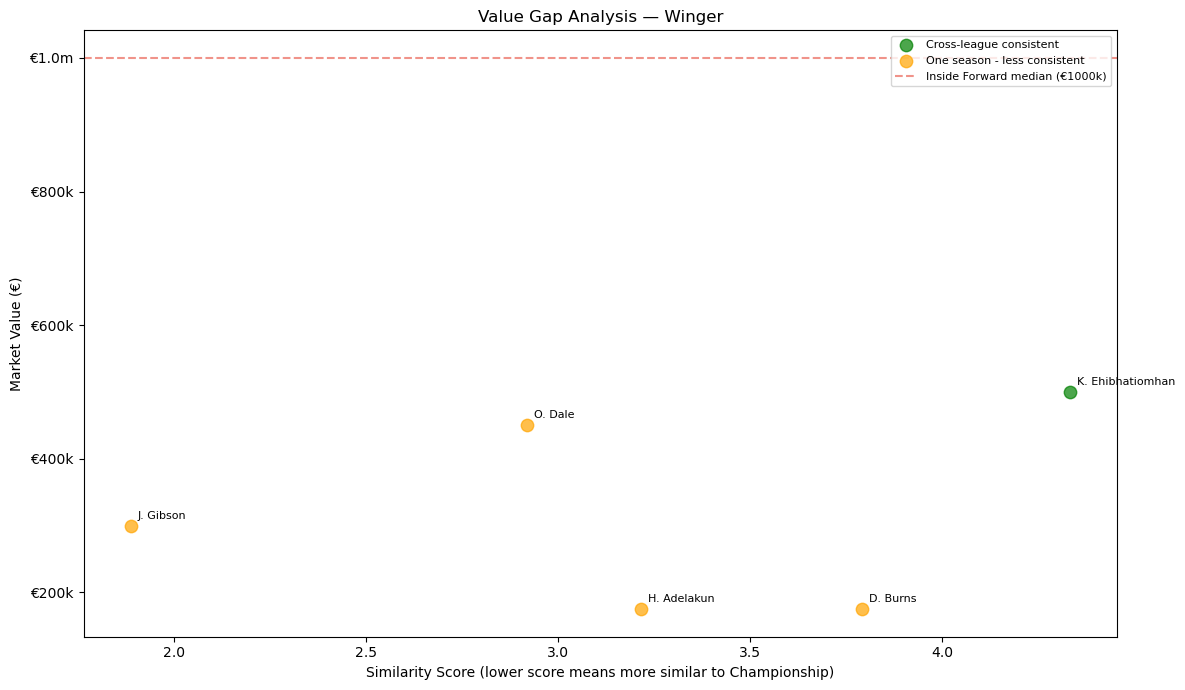

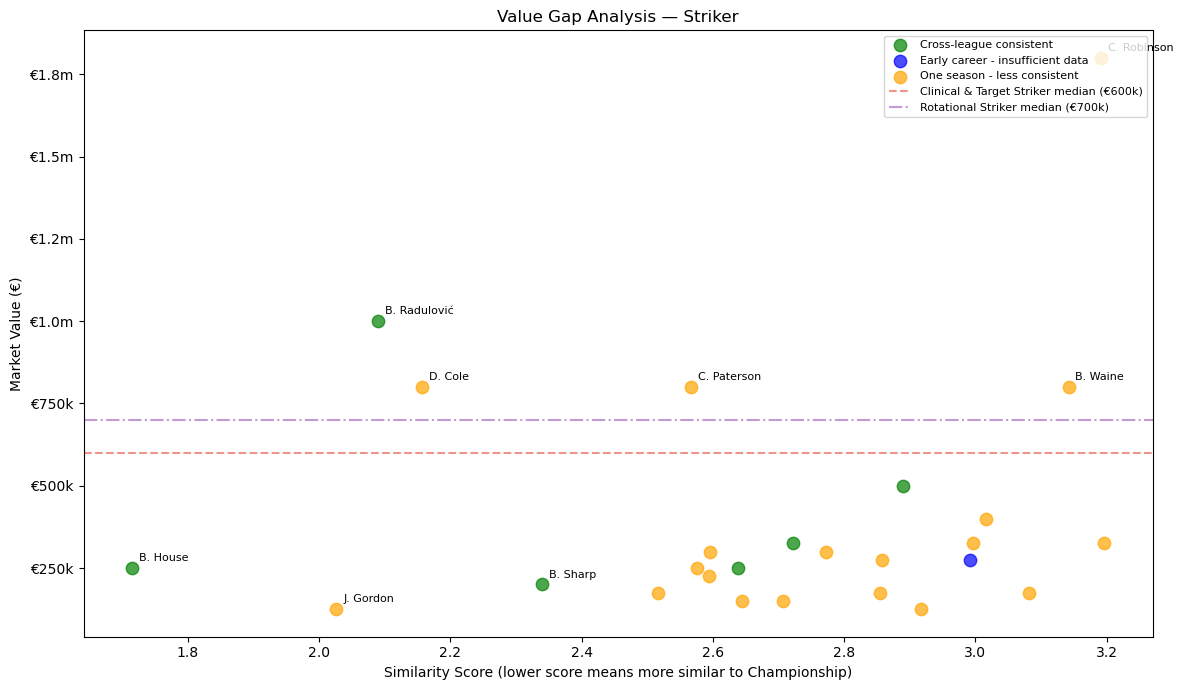

In [59]:
# The first graph that I will produce is a value gap scatter plot - displaying the similarity score (x-axis) Vs the market value (y-axis)
import matplotlib.patches as mpatches

def plot_value_gap(valued_candidates_df, position, league_filter=None):
    df = valued_candidates_df[valued_candidates_df["position"] == position].copy()
    if league_filter:
        df = df[df["league"] == league_filter]
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Adding a colour map to display consistency
    colour_map = {
        "Cross-league consistent": "green",
        "One season - less consistent": "orange",
        "Early career - insufficient data": "blue"
    }
    
    for consistency, group in df.groupby("consistency"):
        ax.scatter(
            group["similarity_score"],
            group["Market value"],
            c=colour_map.get(consistency, "grey"),
            label=consistency,
            alpha=0.7,
            s=80
        )
    
    # Having had a look at the plots, I'm adding player name labels for some of the most interesting candidates: 
    # most similar players and also those that have highest market values and so may be overvalued
    most_similar = df.nsmallest(5, "similarity_score")["Player"].values
    overvalued = df[df["Market value"] > df["champ_cluster_median_value"].max()]["Player"].values
    top_valued = df.nlargest(3, "Market value")["Player"].values
    players_to_label = set(most_similar) | set(overvalued) | set(top_valued)
    for _, row in df[df["Player"].isin(players_to_label)].iterrows():
        ax.annotate(
            row["Player"],
            (row["similarity_score"], row["Market value"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )
    
    # Adding Championship cluster median reference lines (undervalued candidates will appear below the line)
    cluster_medians = df.groupby("cluster_label")["champ_cluster_median_value"].first()

    line_styles = ["--", "-.", ":"]
    line_colours = ["#e74c3c", "#9b59b6", "#e67e22"]    # Researched some more muted colours, less strong than the player points, useful for 
                                                        # reference lines
    for i, (cluster, median) in enumerate(cluster_medians.items()):
        ax.axhline(
            y=median,
            color=line_colours[i % len(line_colours)],
            linestyle=line_styles[i % len(line_styles)],
            alpha=0.6,
            linewidth=1.5,
            label=f"{cluster} median (€{median/1e3:.0f}k)"
        )

    # One of the strikers in the plot has a '?' as the last letter of their name - needs replacing with a 'ć'
    valued_candidates_df["Player"] = valued_candidates_df["Player"].str.replace("?", "ć", regex=False)
    
    ax.set_xlabel("Similarity Score (lower score means more similar to Championship)")
    ax.set_ylabel("Market Value (€)")
    ax.set_title(f"Value Gap Analysis — {position}")
    ax.legend(loc="upper right", fontsize=8)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f"€{x/1e6:.1f}m" if x >= 1e6 else f"€{x/1e3:.0f}k")
    )
    plt.tight_layout()
    plt.savefig(f"outputs/figures/value_gap_{position.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

for position in k_values:
    plot_value_gap(valued_candidates_df, position)

These scatter plots highlight some of the best candidates for Championship moves. The most desirable players for each position lie in the bottom-left quadrant, as these are the players with the best (lowest) similarity score and also have a low market value. It's important to take into account the reference lines, as of course each position and archetype has a unique average market value so those below the reference line for the archetype they are most closely related to should be the most desirable signings.  Players appearing above the Championship cluster median reference lines are valued at or above typical Championship rates for their archetype - representing either fairly-priced proven performers or potentially overvalued assets depending on their similarity score.

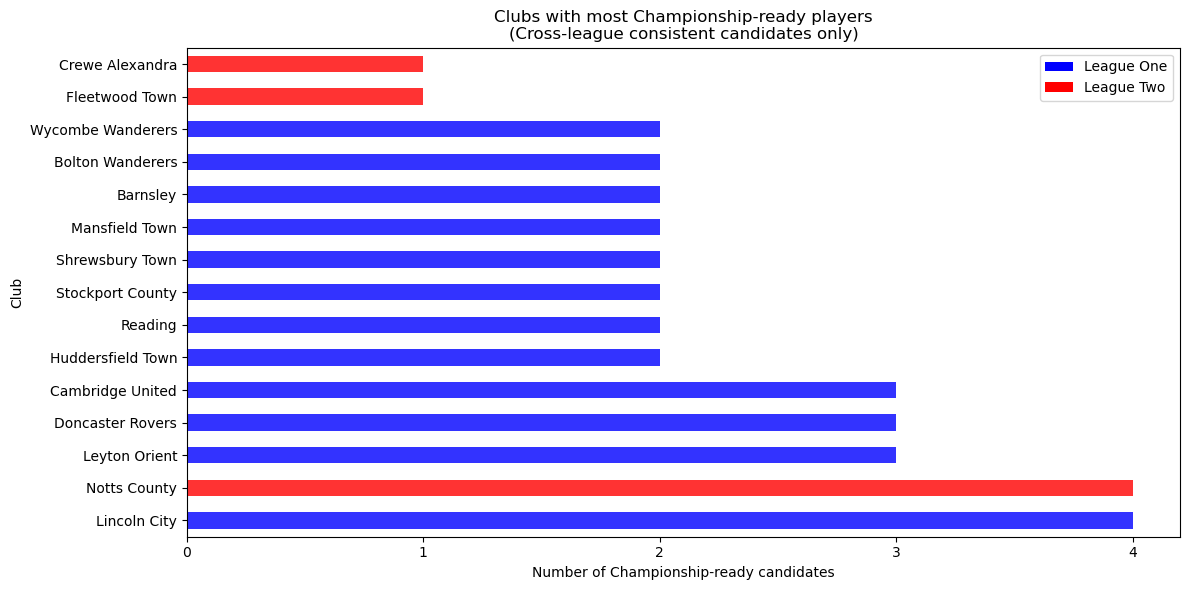

In [60]:
# Now writing a function to evaluate which clubs are producing the most Championship-ready players and hence ahead of others in talent-development
def plot_club_analysis(valued_candidates_df):
    df = valued_candidates_df[valued_candidates_df["consistency"] == "Cross-league consistent"].copy()
    
    club_league = df.groupby("Team within selected timeframe")["league"].first()   # Obtaining the dominant league per club
    
    club_counts = (
        df.groupby("Team within selected timeframe")
        .size()
        .sort_values(ascending=False)
        .head(15)
    )
    
    colours = club_counts.index.map(lambda club: 
        "blue" if "league1" in club_league.get(club, "") else "red"
    )
    
    fig, ax = plt.subplots(figsize=(12, 6))
    club_counts.plot(kind="barh", ax=ax, color=colours, alpha=0.8)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="blue", label="League One"),
        Patch(facecolor="red", label="League Two")
    ]
    ax.legend(handles=legend_elements)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))   # The values on the x-axis are number of players - so only need integers
    ax.set_xlabel("Number of Championship-ready candidates")
    ax.set_ylabel("Club")
    ax.set_title("Clubs with most Championship-ready players\n(Cross-league consistent candidates only)")
    plt.tight_layout()
    plt.savefig("outputs/figures/club_analysis.png", dpi=150, bbox_inches="tight")
    plt.show

plot_club_analysis(valued_candidates_df)

This bar chart shows the clubs with the most 'Championship-ready' players. This definition could be interpreted in different ways but I chose to take, from the valued candidates dataframe, just the players that demonstrated cross-league consistency (since there are no 'Same-league consistent' candidates) . The majority of these teams play in League 1, which is unsurprising since the gap from League 1 to the Championship is much less than the jump from League 2. The fact that Notts County have the joint-most Championship-ready players is impressive considering they haven't been higher than League 2 in over 10 years. Noticeably, the two teams that lead this category were both promoted at the end of the 25/26 season (Lincoln into the Championship and Notts County into League 1) which demonstrates this model's profiling is capturing the player quality that has led to true success on the pitch. Of course, this works both ways as the fact that these two squads won promotion would have been beneficial in inflating these player's statistics.

I'm now going to produce some radar charts. Based on the scatter plots above, I'm going to pick the 'top' candidate from each position to produce a radar chart for. My selection is heavily based on similarity score and consistency, less on the size of their market value. This is becuase from the plots, the player with the smallest similarity score out of all 180 candidates is the Full Back J. Dacres-Cogley, who's market value isn't higher than the reference line but much higher than some other candidates in his position. As a result, he (as is the same for some other strong-looking candidates from the plots) doesn't appear in either shortlist table produced - due to a higher market value, meaning his market value gap % is much less compared to others. For example, S. McLaughlin is part of the shortlist table because his market value is only €75k and hence, since he's a relatively strong candidate and has a much larger market value gap %, he appears within the shortlist. This demonstrates that statistical readiness/similarity and transfer value don't always allign and that there's a difference between being a top-quality option for a Championship club and being the best financial value within your category even if they have a weaker (higher) similarity score within the the valued_candidates_df.

In [61]:
# Using mplsoccer to produce these radar charts
from mplsoccer import Radar

# Defining the lead candidates based on the scatter plots
lead_candidates = {
    "GoalKeeper":           "L. Southwood",
    "Centre Back":          "L. Macari",
    "Full Back":            "J. Dacres-Cogley",
    "Defensive Midfielder": "B. Woods",
    "Attacking Midfielder": "C. Grant",
    "Winger":               "J. Gibson",
    "Striker":              "B. House"
}

# Checking what archetype these candidates are classified as to choose the metrics to display accordingly
for position, player in lead_candidates.items():
    row = valued_candidates_df[valued_candidates_df["Player"] == player].iloc[0]
    print(f"{position}: {player} — {row['cluster_label']}")

GoalKeeper: L. Southwood — Standard Shot-Stopper
Centre Back: L. Macari — Rotational CB
Full Back: J. Dacres-Cogley — Balanced FB
Defensive Midfielder: B. Woods — Ball-Winner DM
Attacking Midfielder: C. Grant — High-Pressing 10
Winger: J. Gibson — Inside Forward
Striker: B. House — Rotational Striker


In [62]:
# Need to obtain the raw (unnormalised) stats for all the lead candidates
def get_player_raw_values(player_name, position, league1and2_pos_dfs):
    for league_key, pos_dfs in league1and2_pos_dfs.items():
        df = pos_dfs[position]
        match = df[df["Player"] == player_name]
        if len(match) > 0:
            return match.iloc[0]
    return None

In [63]:
# Based on the archetypes, selecting the 6 most relevant metrics to include in the radar charts
radar_metrics = {
    "GoalKeeper": [
        "Save rate, %", "Prevented goals per 90",
        "Conceded goals per 90", "Shots against per 90",
        "Accurate long passes, %", "Exits per 90"
    ],

    "Centre Back": [
        "Defensive duels won, %", "Aerial duels won, %",
        "PAdj Interceptions", "PAdj Sliding tackles",
        "Shots blocked per 90", "Fouls per 90"
    ],

    "Full Back": [
        "Progressive runs per 90", "Crosses per 90",
        "Accurate crosses, %", "Key passes per 90",
        "Defensive duels won, %", "PAdj Interceptions"
    ],

    "Defensive Midfielder": [
        "PAdj Interceptions", "PAdj Sliding tackles",
        "Defensive duels won, %", "Aerial duels won, %",
        "Fouls per 90", "Accurate passes, %"
    ],

    "Attacking Midfielder": [
        "Defensive duels won, %", "Progressive runs per 90",
        "Passes to final third per 90", "xA per 90",
        "Key passes per 90", "Successful dribbles, %"
    ],

    "Winger": [
        "Goals per 90", "xG per 90",
        "Touches in box per 90", "Successful dribbles, %",
        "Shots per 90", "Progressive runs per 90"
    ],

    "Striker": [
        "Goals per 90", "xG per 90",
        "Shots per 90", "Shots on target, %",
        "Touches in box per 90", "Aerial duels won, %"
    ]
}

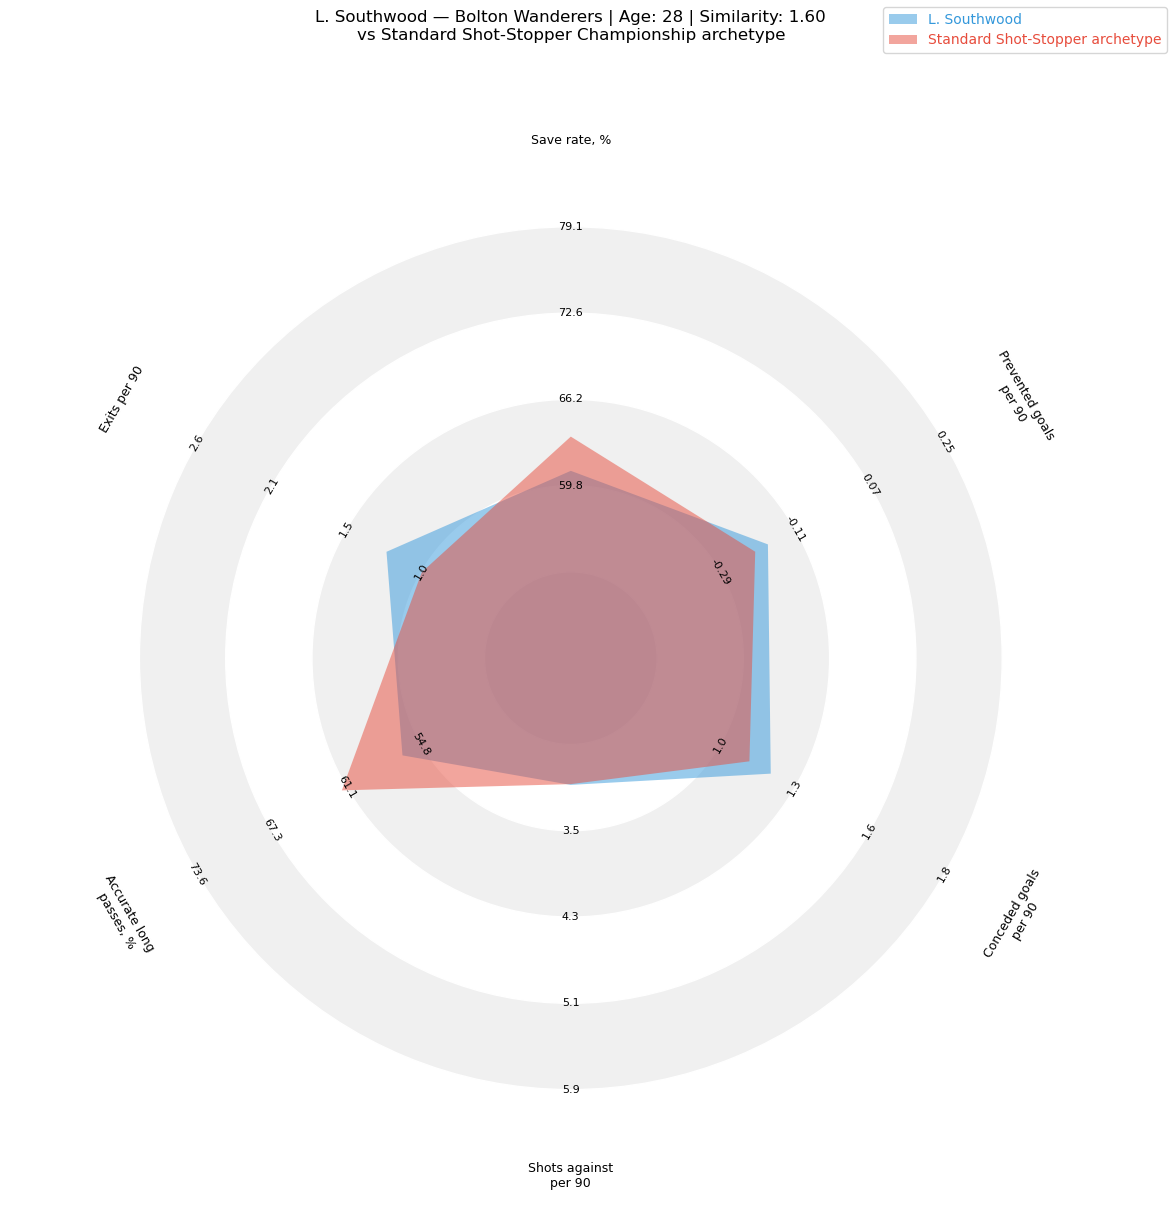

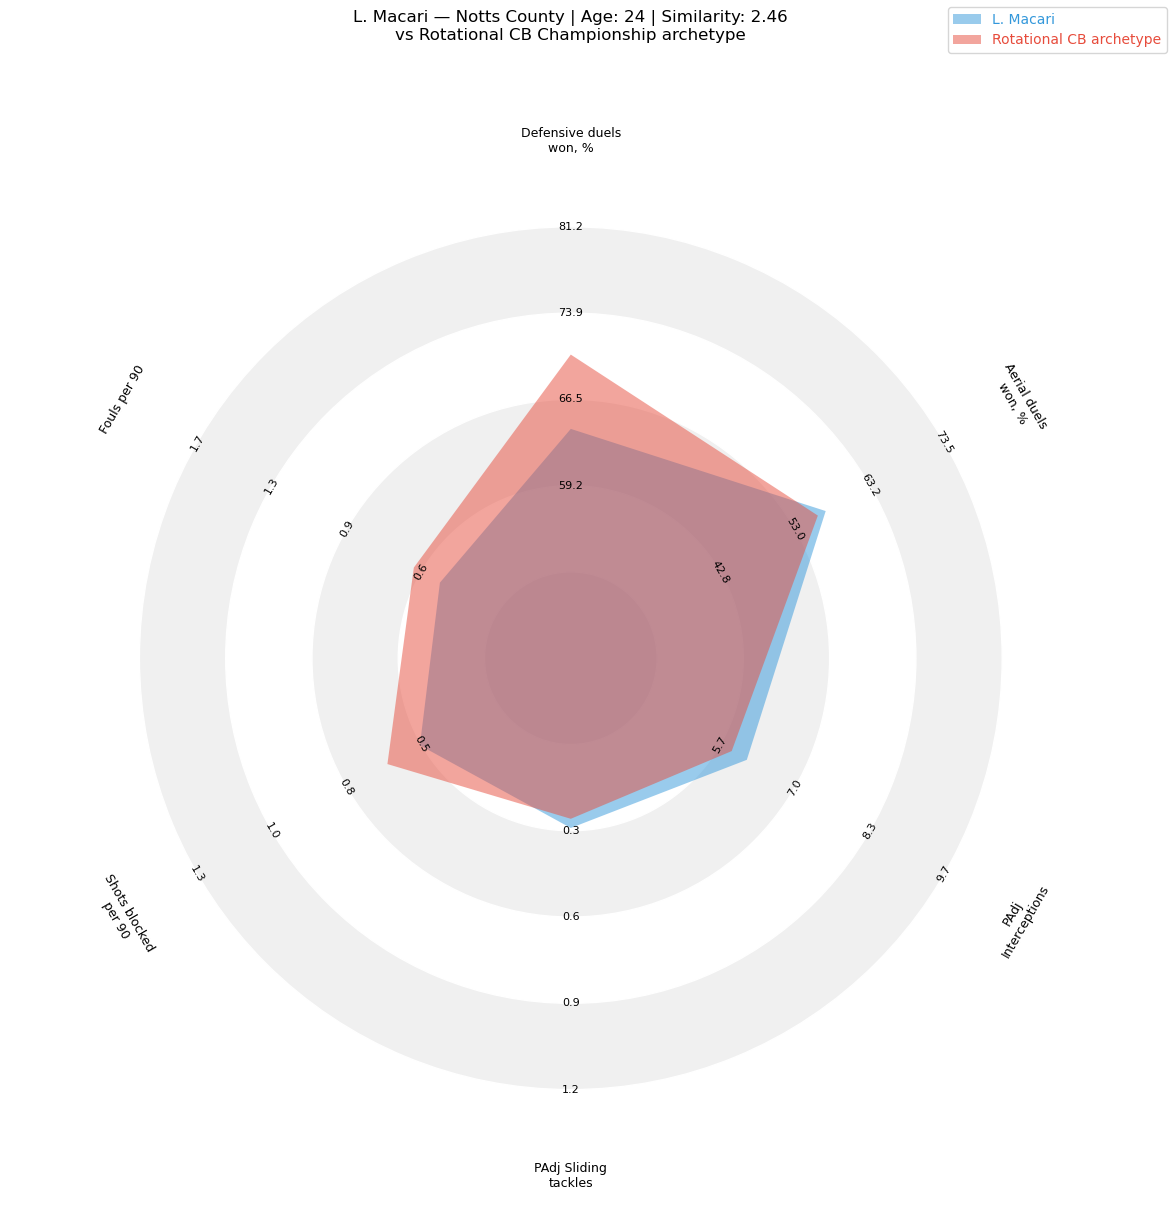

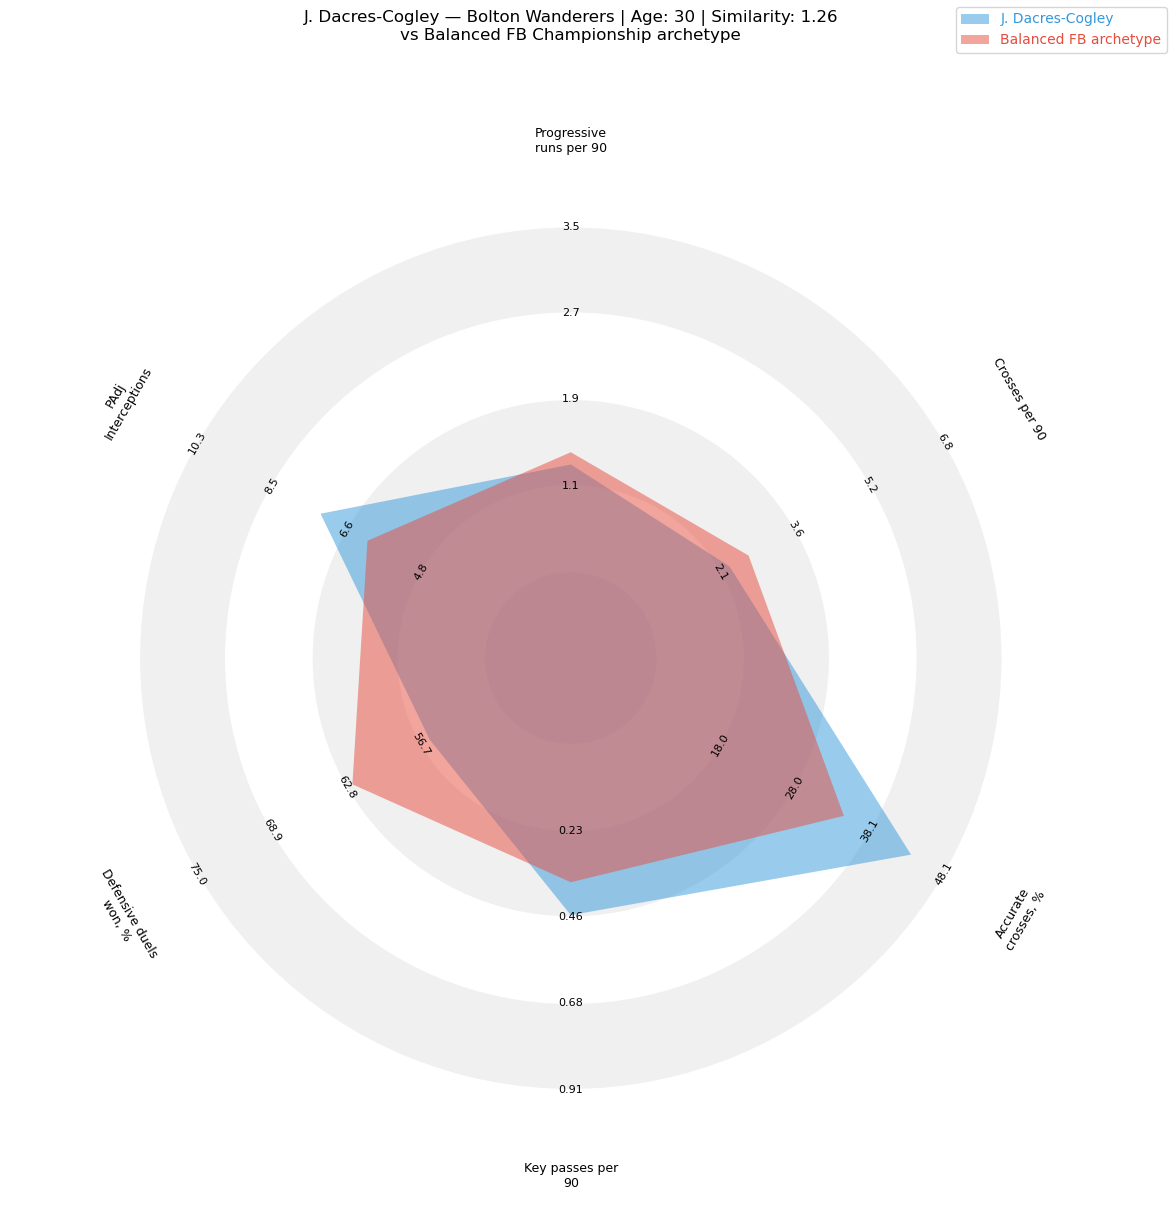

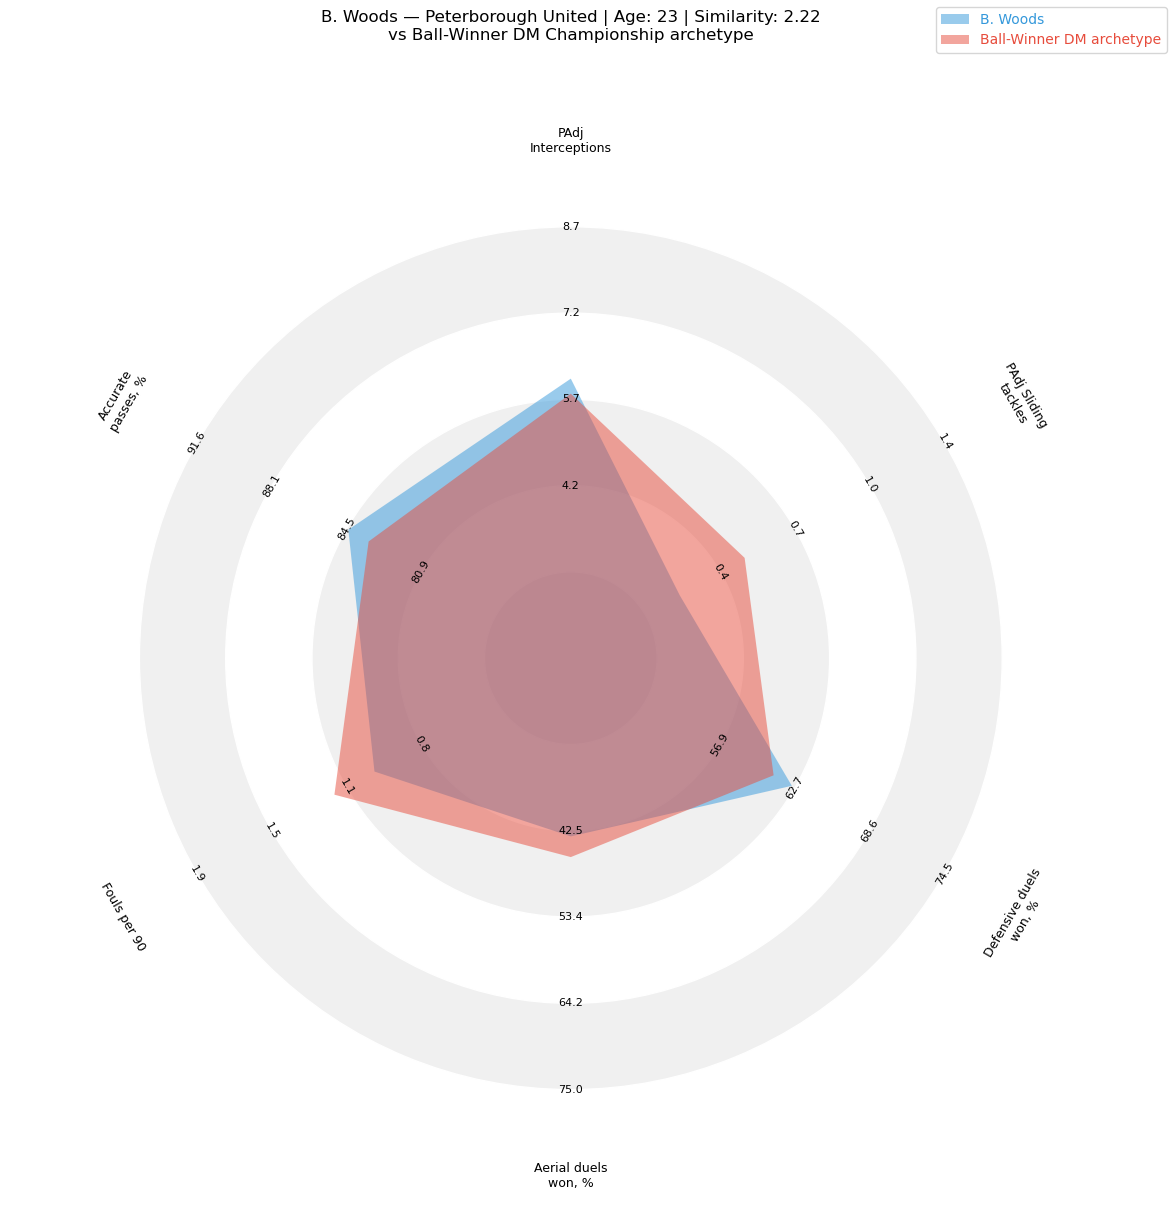

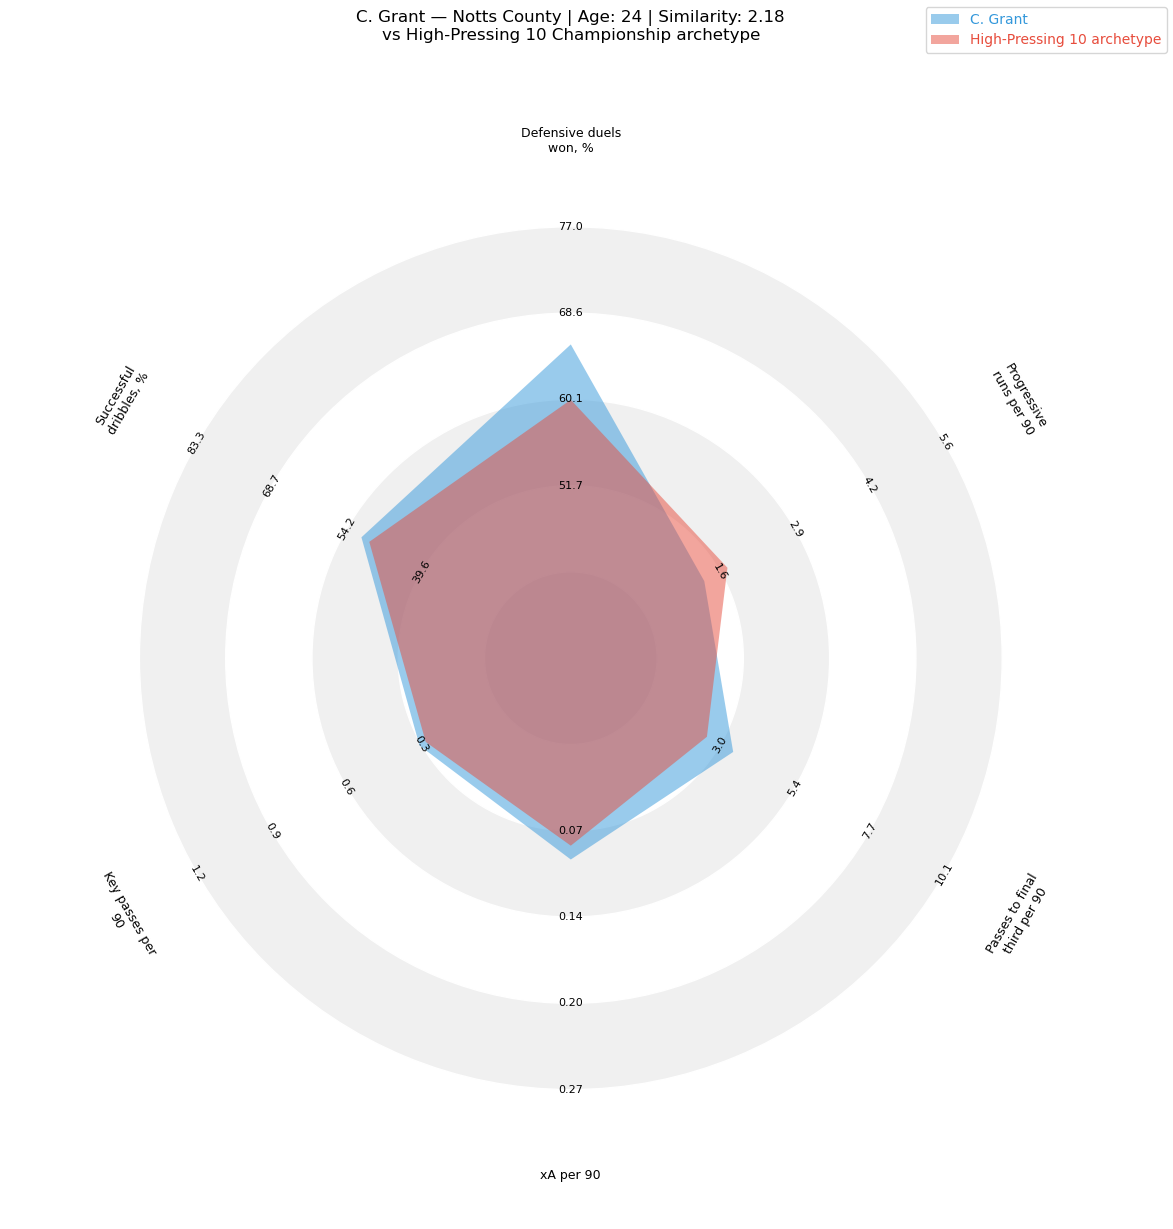

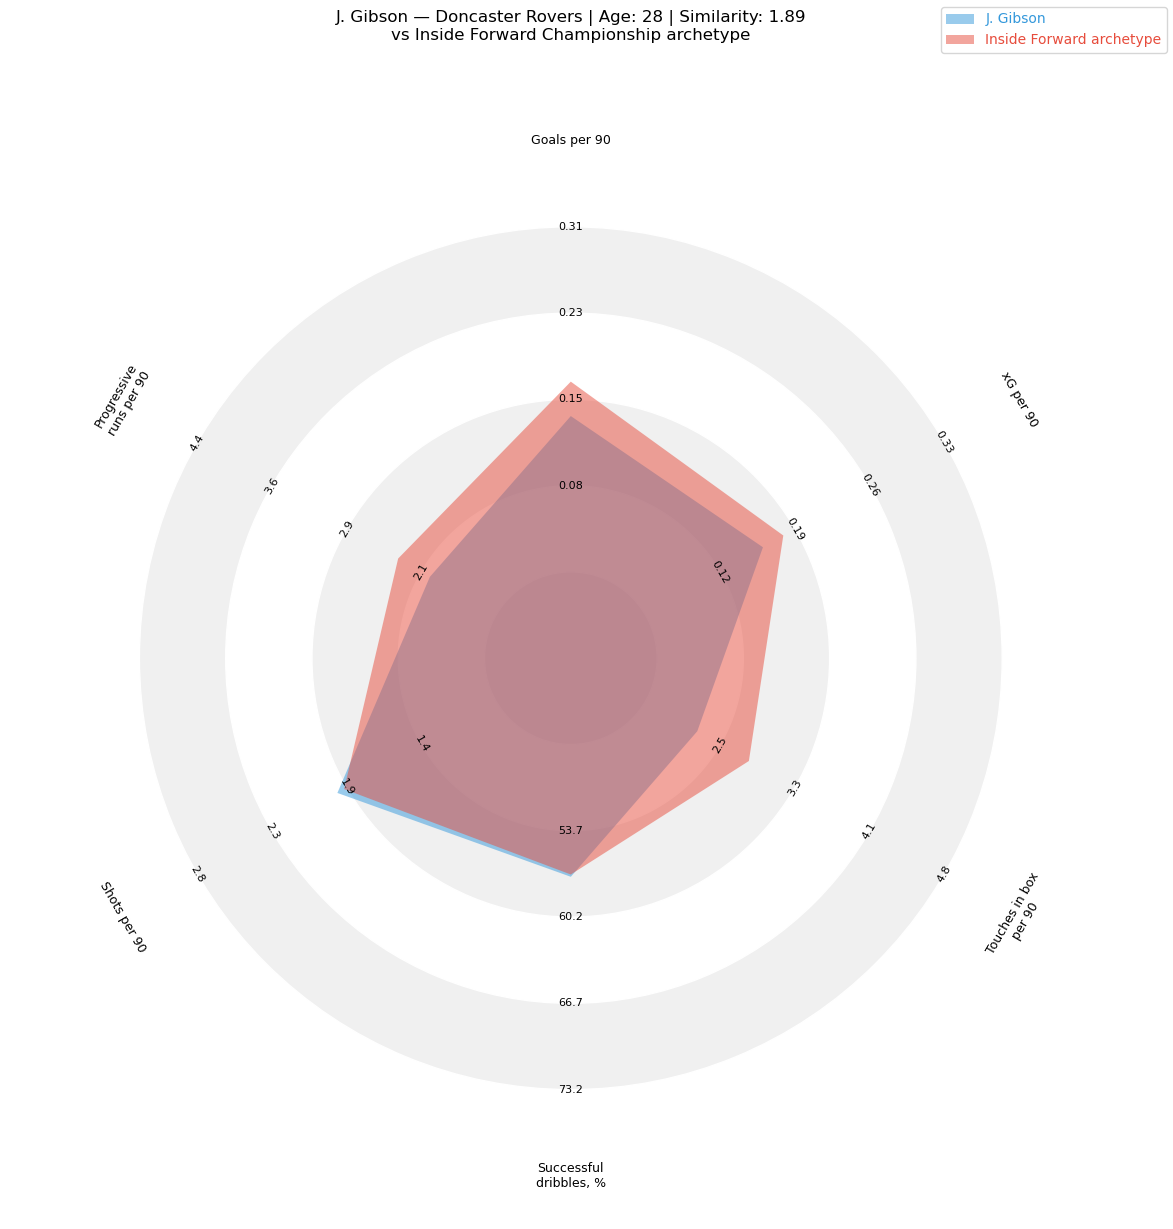

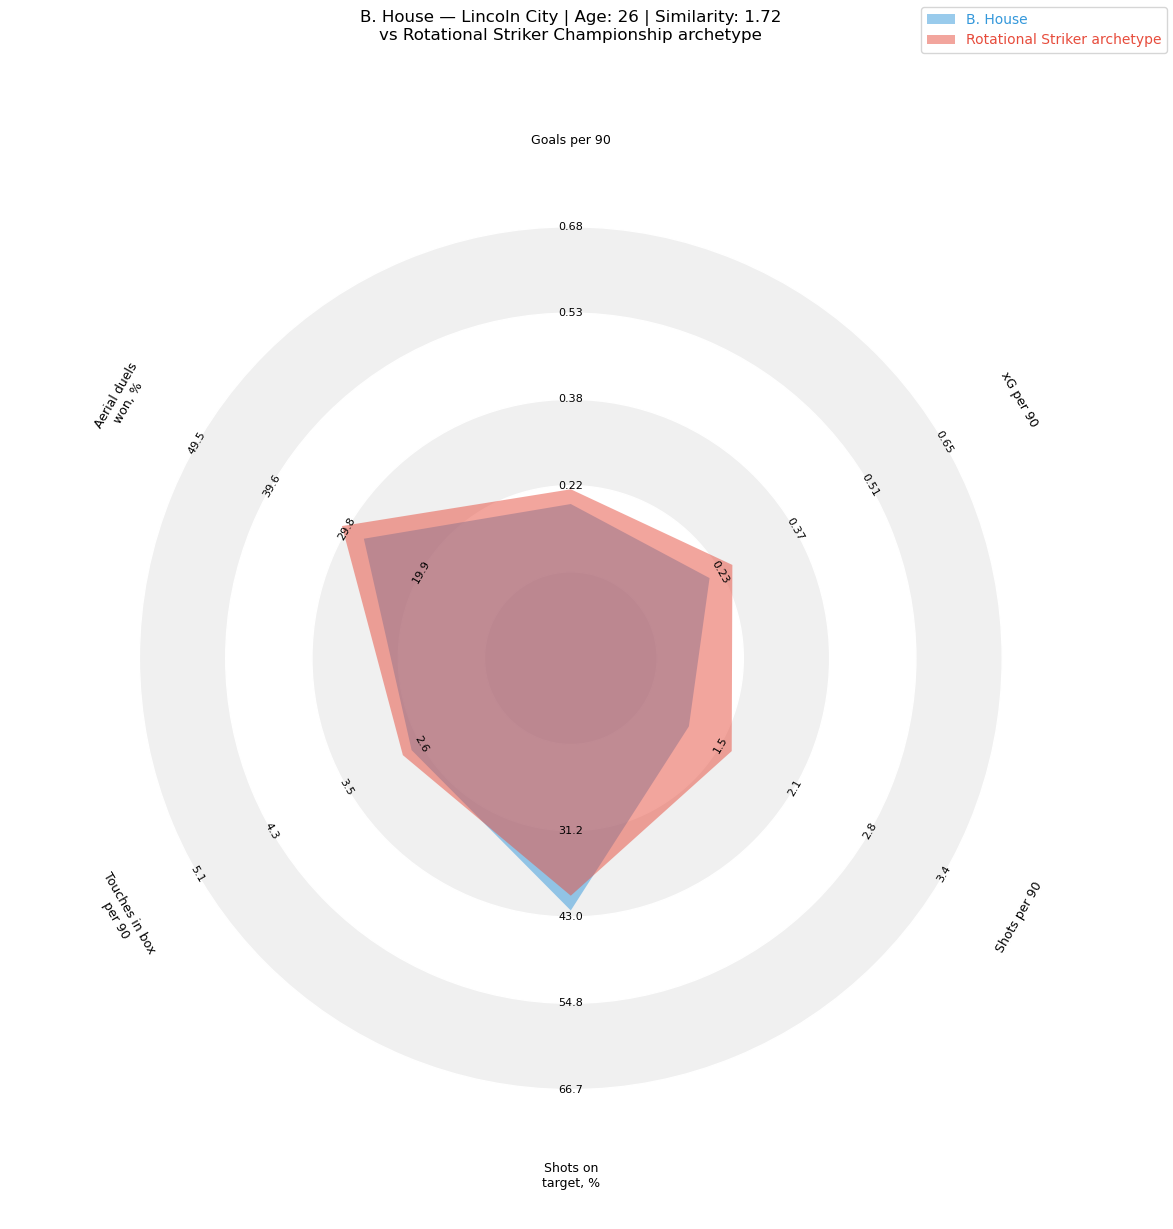

In [64]:
# Creating the plot_radar function to display the radar charts for each lead candidate
def plot_radar(player_name, position, valued_candidates_df, champ_pos_dfs,
               champ_clustered, cluster_labels, radar_metrics, league1and2_pos_dfs):

    player_row = valued_candidates_df[
        valued_candidates_df["Player"] == player_name
    ].iloc[0]

    cluster = player_row["cluster_label"]
    metrics = radar_metrics[position]

    raw_player_row = get_player_raw_values(player_name, position, league1and2_pos_dfs)   # Ensuring the raw values are used
    player_values = raw_player_row[metrics].values.astype(float)

    champ_df = champ_pos_dfs[position].copy()     # Obtaining the Championship archetype mean values
    champ_df["cluster_label"] = champ_clustered[position]["cluster"].map(
        cluster_labels[position]
    )
    archetype_values = champ_df[
        champ_df["cluster_label"] == cluster
    ][metrics].mean().values.astype(float)

    all_values = champ_df[metrics]
    mins = all_values.min().values.astype(float)     # Calculating min/max ranges for scaling
    maxs = all_values.max().values.astype(float)     # by using the Championship position group to set the scale

    radar = Radar(
        params=metrics,
        min_range=mins,
        max_range=maxs,
        round_int=[False] * len(metrics),
        num_rings=4,
        ring_width=1,
        center_circle_radius=1
    )

    fig, ax = radar.setup_axis()
    rings_inner = radar.draw_circles(
        ax=ax, facecolor="#f0f0f0", edgecolor="white"
    )

    
    radar.draw_radar_compare(     # Comparing the candidates stats to the average Championship stats
        player_values,
        archetype_values,
        ax=ax,
        kwargs_radar={"facecolor": "#3498db", "alpha": 0.5},
        kwargs_compare={"facecolor": "#e74c3c", "alpha": 0.5}
    )

    radar.draw_range_labels(ax=ax, fontsize=8)
    radar.draw_param_labels(ax=ax, fontsize=9)

    fig.legend(
        labels=[player_name, f"{cluster} archetype"],
        loc="upper right",
        labelcolor=["#3498db", "#e74c3c"],
        fontsize=10
    )

    club = player_row["Team within selected timeframe"]
    age = int(player_row["Age"])
    similarity = player_row["similarity_score"]

    fig.suptitle(
        f"{player_name} — {club} | Age: {age} | Similarity: {similarity:.2f}\nvs {cluster} Championship archetype",
        fontsize=12,
        y=1.02
    )

    plt.tight_layout()
    plt.savefig(f"outputs/figures/radar_{player_name.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Looping over all players in lead_candidates to display the radar charts
for position, player in lead_candidates.items():
    plot_radar(
        player, position, valued_candidates_df,
        champ_pos_dfs, champ_clustered, cluster_labels, radar_metrics, league1and2_pos_dfs
    )

These radar charts demonstrate the similarity between the lead candidates from League 1/2 and the standard Championship archetype for that position. The polygons are similar in both shape and size which suggests they're style of play is similar and, statistically, they're outputting similar numbers - highlighting their potential to thrive in a Championship club, with deflated market values compared to players already within the Championship.

The players that I've used to produce these radar charts are of course just a select few of the strong candidates, and there are further factors to consider when identifying an optimal Championship signing - like age. A player over 30 could still get a move to the Championship, but it's far less likely in practice compared to an upcoming talent with similar statistics. The primary reason the charts have been used is to demonstrate that the players selected fit their respective Championship archetype well, producing similar (and in some cases superior) statistics in comparison to the Championship standard. 

One standout within the above radar charts is in the attacking midfield position - the Notts County player Conor Grant. Based on the selected position-specific statistics, Grant not only matches but exceeds the standard Championship statistics, whilst fitting the archetype very well. Furthermore, being that he's 24 years old, demonstrates cross-league consistency and is valued at just €225k, he is arguably one of the outstanding candidates across the whole of League 1 and 2 for a Championship move.

Now, for watchlist_candidates_df, producing a ranked table based on similarity score and cross-league consistency to display the top candidates for those without an established market value - potentially identifying some young talent. 

In [65]:
def watchlist_table(watchlist_df, position, n=5):
    df = watchlist_candidates_df[watchlist_candidates_df['position']==position].copy()
    df = df.sort_values('similarity_score', ascending=True)   # Since there's no market value, similarity scores are the decisive factor

    if len(df) == 0:     # Some categories have very few players (particularly wingers) for the watchlist candidates so ensuring there's no error
        print(f"\n{position} — no watchlist candidates")   # if empty groups are encountered
        return
    
    display_cols = [
        "Player", "Team within selected timeframe", "Age",
        "cluster_label", "similarity_score", "consistency"
    ]
    
    print(f"\nWatchlist — {position} (no market value recorded):")
    print(df[display_cols].head(n).to_string(index=False))
 
for position in k_values:
    watchlist_table(watchlist_candidates_df, position)


Watchlist — GoalKeeper (no market value recorded):
   Player Team within selected timeframe  Age         cluster_label  similarity_score                      consistency
K. Cahill                  Leyton Orient 22.0 Standard Shot-Stopper          2.151416     One season - less consistent
O. Wright             Accrington Stanley 23.0       High Quality #1          2.293689     One season - less consistent
T. Simkin                  Leyton Orient 21.0               Busy GK          2.446918 Early career - insufficient data

Watchlist — Centre Back (no market value recorded):
      Player Team within selected timeframe  Age   cluster_label  similarity_score                      consistency
L. Woodhouse                    Exeter City 21.0 Ball-Playing CB          2.738383 Early career - insufficient data
     J. Kerr                 Wigan Athletic 29.0 Ball-Playing CB          3.052327          Cross-league consistent
   C. Raglan                         Barrow 33.0    Defensive CB       

There are some strong candidates to consider based on these watchlist tables. 

Firstly, the striker W. Davies - he has a similarity score of 1.76, the lowest in the entire watchlist and similar to some of the top valued candidates. He's 27-year-old so arguably at the prime of his career, with profiling almost identically to a Championship Rotational Striker.

Next, the full back J. McGregor who's only 20 years old, cross-league consistent, with a similarity score of 2.45. The combination of youth, consistency across leagues and no established market value means he's a very strong candidate.

The defensive midfielder J. Bland is 21 years old, with a similarity score of 2.52. He's categorised as 'Early career' and so it's unsurpirsing he's yet to have an established market value but appears to be a young ball-winner with Championship-level defensive metrics. 

Similarly, the attacking midfielder T. Brenan is only 19 years old, also with an part of the 'Early career' group with a similarity score of 2.95. He may be too young to have a market value but is already profiling similarly to a Championship High-Pressing 10.

Finally, the centre back L. Woodhouse who is 21 years old, in his early career and fits the 'Ball-Playing CB' archetype. He is another young player with no market value but strong Championship similarity, particularly impressive since he was playing for a side that were relegated from League 1 in the 25/26 season. 

Many of the candidates from these watchlist tables play for mid-table or lower clubs and so it's arguably even more impressive that they have the scores that they do, compared to players within a team thriving in their respective league. It may be that the players in these watchlist tables are some of the best 'undiscovered' talents from League 1 and 2, that are certainly capable of stepping up to the Championship level.

My final ouput is going to be a headline table - combining both valued and watchlist candidates. This will be based on similarity score and age, only focusing on the players with large development potential (28 and under).

In [66]:
def headline_table(valued_candidates_df, watchlist_candidates_df, position, n=3, max_age=28):
    headline_df = pd.concat([valued_candidates_df, watchlist_candidates_df], ignore_index=True)   # Need to join the 2 dataframes first
    headline_df["Market value"] = headline_df["Market value"].replace(0, pd.NA)  # Replacing the 0s in market value column with NaN

    headline_df["Market value"] = headline_df["Market value"].apply(   # Formatting the display of the market value 
    lambda x: f"€{x/1e3:.0f}k" if pd.notna(x) else "Not recorded"
    )
    
    df = headline_df[headline_df['position']==position].copy()
    df = df[df['Age']<=max_age]        # Applying the age filter
    df = df[df['season']=='25/26']     # and taking only the primary season 25/26 (so no reference players from 24/25)
    df = df[df["value_gap_pct"] >= 0]  # Also, ensuring only players with a positive value gap are included, for true 'undervalued' identification

    headline_cols = [
    "Player", "Team within selected timeframe", "position",
    "Age", "cluster_label", "similarity_score",
    "Market value", "value_gap_pct", "consistency"
    ]

    df = df.sort_values(['similarity_score', 'Age'], ascending=[True, True])

    print(f"\nHeadline Table — {position} (combined valued and watchlist candidates):")
    print(df[headline_cols].head(n).to_string(index=False))

for position in k_values:
    headline_table(valued_candidates_df, watchlist_candidates_df, position)


Headline Table — GoalKeeper (combined valued and watchlist candidates):
   Player Team within selected timeframe   position  Age         cluster_label  similarity_score Market value  value_gap_pct                  consistency
K. Cahill                  Leyton Orient GoalKeeper 22.0 Standard Shot-Stopper          2.151416 Not recorded          100.0 One season - less consistent
O. Wright             Accrington Stanley GoalKeeper 23.0       High Quality #1          2.293689 Not recorded          100.0 One season - less consistent
J. Keeley                     Luton Town GoalKeeper 23.0       High Quality #1          2.409843        €200k           71.4      Cross-league consistent

Headline Table — Centre Back (combined valued and watchlist candidates):
     Player Team within selected timeframe    position  Age cluster_label  similarity_score Market value  value_gap_pct                  consistency
  L. Macari                   Notts County Centre Back 24.0 Rotational CB          2.455

## Headline Findings - Championship-Ready Talent in EFL League One & Two

Based on both the valued and watchlist candidates, taking into account similarity score, consistency, age (focus on 28 years old and under) and market value gap (for the valued candidates) this is a select list of players that the model identifies as the most capable of thriving in the EFL Championship, at a price that likely undermines their true quality:

- **C. Grant (Notts County, AM, age 24)** - the model's standout individual finding. 
Cross-league consistent across two seasons, profiling as a High-Pressing 10 with a 
similarity score of 2.18 and valued at just €225k against a €1m Championship cluster 
median. The radar chart confirms he not only matches but exceeds the Championship 
archetype average in defensive duels and passes into the final third.

- **N. Guinness-Walker (Northampton Town, FB, age 26)** - cross-league consistent 
with an 86.1% value gap. One of the lowest similarity scores among valued full back candidates, 
suggesting strong Championship readiness at a fraction of typical market rates - despite
playing for a team that finished bottom of League 1 in the 25/26 season.

- **W. Davies (Fleetwood Town, ST, age 27)** - the strongest watchlist finding with a 
similarity score of 1.76, the lowest of any striker in the dataset. No market value 
recorded on Wyscout, suggesting he may represent exceptional value for a data-driven 
Championship club willing to look beyond established valuations.

- **J. Bland (Barnsley, DM, age 21)** - the youngest player in the headline table. 
Flagged as early career with insufficient prior season data, but his Championship-level 
Ball-Winner profile at 21 years old with no market value makes him one of the most 
intriguing long-term prospects identified.

### Real-world validation

As mentioned earlier, **Lincoln City** and **Notts County** - identified by the club analysis as 
the two clubs with the most Championship-ready players (4 candidates each) and numerous candidates in the shortlist tables - both 
earned promotion at the end of the 25/26 season. This correlation between squad-level 
Championship readiness and actual promotion success provides encouraging real-world 
validation of the model's profiling methodology.


In [68]:
# Finally, creating a figures.zip file to download all figures from the Noteable environment I'm working on
import shutil

shutil.make_archive("figures", "zip", "outputs/figures")
print("figures.zip created")

figures.zip created
